# Strategy evidence synthesis

**Objective.** Consolidate the completed strategy chain into one aggregate-only
evidence hierarchy before Gate F1, refreshed through Notebook 70. The notebook
asks two bounded questions:

1. Which strategy is a defensible working base once evidence quality is considered?
2. Does any sentiment-enhanced rule earn promotion over that base?

This notebook loads only aggregate CSV/JSON artifacts. It does **not** load prices,
returns, positions, headlines, or licensed text, and it does not search parameters.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SEED = 20260805
np.random.seed(SEED)

ROOT = Path.cwd()
if not (ROOT / "final_experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "final_experiments").exists(), "Run from the repository root or final_experiments/."

OUTPUT = ROOT / "final_experiments/outputs/44_strategy_evidence_synthesis"
OUTPUT.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)


def read_csv(relative: str) -> pd.DataFrame:
    path = ROOT / relative
    assert path.suffix == ".csv", f"Aggregate-only boundary violated: {path}"
    return pd.read_csv(path)


def read_json(relative: str) -> dict:
    path = ROOT / relative
    assert path.suffix == ".json", f"Aggregate-only boundary violated: {path}"
    return json.loads(path.read_text())


def sha256(relative: str) -> str:
    path = ROOT / relative
    return hashlib.sha256(path.read_bytes()).hexdigest()


def one(frame: pd.DataFrame, **filters: object) -> pd.Series:
    mask = pd.Series(True, index=frame.index)
    for column, value in filters.items():
        mask &= frame[column].eq(value)
    selected = frame.loc[mask]
    assert len(selected) == 1, f"Expected one row for {filters}; found {len(selected)}"
    return selected.iloc[0]


def git_commit() -> str:
    return subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()

## Frozen decision policy

The ordinal evidence score below is a display aid, not a statistical weight:

- **5** — independent, price-only benchmark fitted before evaluation;
- **4** — frozen chronological or external-time test;
- **3** — frozen cross-period stress test with a previously opened research chain;
- **2** — bounded retrospective robustness on an opened outcome window;
- **1** — explicitly post-result diagnostic.

A sentiment rule can be promoted only if its paired net-return interval excludes zero
in the favourable direction, its effect is temporally stable, its local predeclared
gate passes, and its evidence score is at least 4. A high retrospective Sharpe cannot
compensate for failing those conditions. The sentiment-free HAR target is assessed as
a conventional research benchmark, not as a claim of sentiment alpha or a
deployment-qualified strategy. Notebook 46's external-time transfer is binding for
any claim that the base itself is stable.

In [2]:
paths = {
    "n20_results": "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/results.csv",
    "n20_gates": "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/gates.csv",
    "n21_results": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/strategy_results.csv",
    "n21_gates": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/gates.csv",
    "n21_inference": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/strategy_inference.csv",
    "n23_results": "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/results.csv",
    "n23_gates": "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/gates.csv",
    "n24_results": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/results.csv",
    "n24_gates": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/gates.csv",
    "n24_inference": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/paired_inference.csv",
    "n25_results": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/results.csv",
    "n25_gates": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/gates.csv",
    "n25_inference": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/paired_inference.csv",
    "n26_results": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/results.csv",
    "n26_gates": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/gates.csv",
    "n26_inference": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/paired_inference.csv",
    "n27_results": "final_experiments/outputs/27_fnspid_har_sentiment_composition/results.csv",
    "n27_gates": "final_experiments/outputs/27_fnspid_har_sentiment_composition/gates.csv",
    "n27_inference": "final_experiments/outputs/27_fnspid_har_sentiment_composition/paired_inference.csv",
    "n36_result": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/hybrid_result.csv",
    "n36_gates": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/gates.csv",
    "n40_results": "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/strategy_results.csv",
    "n40_gates": "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/gates.csv",
    "n42_results": "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/strategy_results.csv",
    "n42_gates": "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/gates.csv",
    "n43_results": "final_experiments/outputs/43_lseg_gemma_story_family_first_release/strategy_results.csv",
    "n43_inference": "final_experiments/outputs/43_lseg_gemma_story_family_first_release/inference.csv",
    "n46_results": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/strategy_results.csv",
    "n46_gates": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/gates.csv",
    "n46_inference": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/paired_inference.csv",
    "n46_forecast_inference": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/forecast_inference.csv",
    "n47_results": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/results.csv",
    "n47_gates": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/gates.csv",
    "n47_inference": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/inference.csv",
    "n48_results": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/results.csv",
    "n48_gates": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/gates.csv",
    "n48_inference": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/inference.csv",
    "n49_results": "final_experiments/outputs/49_lseg_gemma_story_revision_sign_flip/results.csv",
    "n49_gates": "final_experiments/outputs/49_lseg_gemma_story_revision_sign_flip/gates.csv",
    "n49_inference": "final_experiments/outputs/49_lseg_gemma_story_revision_sign_flip/inference.csv",
    "n50_results": "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/results.csv",
    "n50_gates": "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/gates.csv",
    "n50_inference": "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/paired_inference.csv",
    "n51_curve": "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/capacity_curve.csv",
    "n51_gates": "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/gates.csv",
    "n52_input_gate": "final_experiments/outputs/52_lseg_gemma_hybrid_liquidity_aware_sizing/input_gate.csv",
    "n52_gates": "final_experiments/outputs/52_lseg_gemma_hybrid_liquidity_aware_sizing/gates.csv",
    "n53_coverage": "final_experiments/outputs/53_lseg_prospective_population_gate/collection_coverage_audit.csv",
    "n53_gate": "final_experiments/outputs/53_lseg_prospective_population_gate/population_gate.csv",
    "n54_summary": "final_experiments/outputs/54_lseg_prospective_batch_ledger/population_summary.csv",
    "n54_gate": "final_experiments/outputs/54_lseg_prospective_batch_ledger/population_gate.csv",
    "n55_registry": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/strategy_registry_row.csv",
    "n56_families": "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/family_summary.csv",
    "n56_arms": "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/arm_inventory.csv",
    "n56_gates": "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/gates.csv",
    "n57_decision": "final_experiments/outputs/57_aggregate_candidate_base_frontier/decision.csv",
    "n58_frontier": "final_experiments/outputs/58_lseg_gemma_hybrid_capacity_uncertainty/uncertainty_frontier.csv",
    "n59_components": "final_experiments/outputs/59_lseg_gemma_hybrid_session_decomposition/component_inference.csv",
    "n59_legs": "final_experiments/outputs/59_lseg_gemma_hybrid_session_decomposition/leg_summary.csv",
    "n60_inference": "final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/control_inference.csv",
    "n60_summary": "final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/control_summary.csv",
    "n61_inference": "final_experiments/outputs/61_lseg_gemma_hybrid_long_leg_sector_component/component_inference.csv",
    "n62_manifest": "final_experiments/outputs/62_lseg_cash_flow_distance_reliability_gate/manifest.json",
    "n63_manifest": "final_experiments/outputs/63_lseg_gemma_hybrid_long_leg_characteristic_attribution/manifest.json",
    "n64_manifest": "final_experiments/outputs/64_lseg_gemma_hybrid_long_leg_residual_portfolios/manifest.json",
    "n65_manifest": "final_experiments/outputs/65_lseg_gemma_hybrid_specificity_filter/manifest.json",
    "n67_manifest": "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/manifest.json",
    "n70_results": "final_experiments/outputs/70_lseg_gemma_continuous_joined_long_window/strategy_results.csv",
    "n70_cash": "final_experiments/outputs/70_lseg_gemma_continuous_joined_long_window/cash_inference.csv",
    "n70_manifest": "final_experiments/outputs/70_lseg_gemma_continuous_joined_long_window/manifest.json",
}

tables = {
    name: read_json(path) if path.endswith(".json") else read_csv(path)
    for name, path in paths.items()
}
source_files = pd.DataFrame(
    [{"source": name, "path": path, "sha256": sha256(path)} for name, path in paths.items()]
)
assert source_files["path"].str.endswith((".csv", ".json")).all()
source_files.to_csv(OUTPUT / "source_files.csv", index=False)

display(Markdown(f"Loaded **{len(source_files)} aggregate artifacts**; no row-level return or text file was read."))

Loaded **70 aggregate artifacts**; no row-level return or text file was read.

## Strategy evidence registry

Raw Sharpe ratios are shown, but the rows are not treated as one commensurate horse
race: universes, dates, costs, and selection histories differ. `promotion_pass` applies
the rule-specific gate in the source notebook. `decision_eligible` applies the stricter
cross-notebook evidence policy declared above.

In [3]:
n20_hyst = one(tables["n20_results"], split="evaluation", arm="hysteresis")
n21_har = one(tables["n21_results"], arm="control_har_target")
n21_sent = one(tables["n21_results"], arm="sentiment_har_target")
n23_sent = one(tables["n23_results"], arm="trend_200_har_sentiment")
n24_product = one(tables["n24_results"], arm="har_sentiment")
n25_product = one(tables["n25_results"], arm="walkforward_har_sentiment")
n26_brake = one(tables["n26_results"], period="full", arm="firm_brake")
n27_cap = one(tables["n27_results"], era="evaluation", arm="absolute_cap")
n36_hybrid = tables["n36_result"].iloc[0]
n40_eval = one(tables["n40_results"], split="evaluation", strategy="adaptive_dispersion")
n42_adaptive = one(tables["n42_results"], strategy="adaptive_dispersion")
n43_filtered = one(tables["n43_results"], strategy="first_release_only")
n46_har = one(tables["n46_results"], arm="frozen_har")
n46_constant = one(tables["n46_results"], arm="constant_matched_har")
n46_overlay = one(tables["n46_results"], arm="har_gemma_breadth_overlay")
n47_revision = one(tables["n47_results"], arm="revision_delta")
n47_level = one(tables["n47_results"], arm="matched_latest_level")
n48_event = one(tables["n48_results"], arm="one_session_event")
n48_state = one(tables["n48_results"], arm="persistent_state")
n49_flip = one(tables["n49_results"], arm="strict_sign_flip")
n50_equal = one(tables["n50_results"], rule="equal_weight_hybrid")
n50_risk = one(tables["n50_results"], rule="inverse_volatility_hybrid")
n51_primary_one = one(
    tables["n51_curve"], impact_coefficient=1.0, initial_aum_usd=1_000_000.0
)
n51_primary_ten = one(
    tables["n51_curve"], impact_coefficient=1.0, initial_aum_usd=10_000_000.0
)
n51_primary_twenty_five = one(
    tables["n51_curve"], impact_coefficient=1.0, initial_aum_usd=25_000_000.0
)
n51_registry = n51_primary_ten.copy()
n51_registry["max_drawdown"] = n51_registry["maximum_drawdown"]
n52_input = tables["n52_input_gate"].iloc[0]
n53_coverage = tables["n53_coverage"].iloc[0]
n53_calendar_gate = one(
    tables["n53_gate"], gate="complete_price_calendar_sessions"
)
n53_manifest = read_json(
    "final_experiments/outputs/53_lseg_prospective_population_gate/manifest.json"
)
assert n53_manifest["status"] == "stopped_before_scoring_and_returns"
n54_summary = tables["n54_summary"].iloc[0]
n54_calendar_gate = one(
    tables["n54_gate"], gate="complete_price_calendar_sessions"
)
n54_manifest = read_json(
    "final_experiments/outputs/54_lseg_prospective_batch_ledger/manifest.json"
)
assert n54_manifest["status"] == "stopped_before_scoring_prices_and_returns"
assert (
    int(n53_calendar_gate["observed_or_upper_bound"])
    == int(n54_calendar_gate["observed_or_upper_bound"])
    == int(n54_summary["calendar_sessions_available"])
)
assert n54_manifest["planning_cost"]["quote_or_authorisation"] is False
assert n54_manifest["stop_controls"]["paid_external_gemma_scoring_authorised"] is False
assert n54_manifest["stop_controls"]["price_data_loaded"] is False

n55_registry_row = tables["n55_registry"].iloc[0]
n55_manifest = read_json(
    "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/manifest.json"
)
assert n55_manifest["status"] == "complete_aggregate_only_reconciliation_no_new_return_construction"
assert n55_manifest["input_boundary"]["new_return_constructed"] is False
assert n55_manifest["input_boundary"]["scorer_launched"] is False
assert n55_manifest["decision"]["sentiment_promoted"] is False
assert n55_manifest["decision"]["deployment_qualified_base"] is False

n56_manifest = read_json(
    "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/manifest.json"
)
n56_magnitude = one(tables["n56_arms"], family="midcap_vaderc_v2", arm="finbert_magnitude")
assert n56_manifest["status"] == "complete_aggregate_only_lineage_audit_no_new_returns"
assert int(tables["n56_families"]["descriptive_floor_pass"].sum()) == 1
assert bool(one(tables["n56_gates"], gate="n55_captures_only_passing_family")["pass"])
assert not bool(one(tables["n56_gates"], gate="another_distinct_positive_covered_base_omitted")["pass"])
assert n56_manifest["decision"]["new_return_constructed"] is False
assert n56_manifest["decision"]["strategy_promoted"] is False

n57_decision_row = tables["n57_decision"].iloc[0]
n57_manifest = read_json(
    "final_experiments/outputs/57_aggregate_candidate_base_frontier/manifest.json"
)
assert n57_manifest["status"] == "complete_aggregate_only_candidate_base_audit_no_new_returns"
assert n57_manifest["input_boundary"]["new_signal_constructed"] is False
assert n57_manifest["input_boundary"]["new_return_constructed"] is False
assert n57_manifest["policy"]["candidate_reselected_from_notebook_57_outcomes"] is False
assert n57_manifest["policy"]["prospective_contract_changed"] is False
assert n57_manifest["decision"]["retrospective_economic_candidate"] is True
assert n57_manifest["decision"]["validated_alpha"] is False
assert n57_manifest["decision"]["deployment_qualified"] is False

n58_one = one(tables["n58_frontier"], initial_aum_usd=1_000_000.0)
n58_ten = one(tables["n58_frontier"], initial_aum_usd=10_000_000.0)
n58_manifest = read_json(
    "final_experiments/outputs/58_lseg_gemma_hybrid_capacity_uncertainty/manifest.json"
)
assert n58_manifest["status"] == "RETROSPECTIVE_OPENED_WINDOW_UNCERTAINTY_AWARE_CAPACITY_DIAGNOSTIC"
assert n58_manifest["decision"]["passing_grid_points"] == 0
assert n58_manifest["decision"]["uncertainty_aware_capacity_aum_usd"] is None
assert n58_manifest["claim_boundary"]["strategy_reselected"] is False
assert n58_manifest["claim_boundary"]["prospective_contract_changed"] is False

n59_intraday = one(tables["n59_components"], component="intraday")
n59_overnight = one(tables["n59_components"], component="overnight")
n59_long = one(tables["n59_legs"], leg="long")
n59_short = one(tables["n59_legs"], leg="short")
n59_manifest = read_json(
    "final_experiments/outputs/59_lseg_gemma_hybrid_session_decomposition/manifest.json"
)
assert n59_manifest["status"] == "RETROSPECTIVE_OPENED_WINDOW_SESSION_COMPONENT_DECOMPOSITION"
assert n59_manifest["decision"]["mechanism_class"] == "intraday_only"
assert n59_manifest["claim_boundary"]["strategy_reselected"] is False
assert n59_manifest["claim_boundary"]["prospective_contract_changed"] is False

n60_market = one(
    tables["n60_inference"], comparison="selected_long_minus_equal_weight_market"
)
n60_sector = one(
    tables["n60_inference"], comparison="selected_long_minus_same_sector_equal_weight"
)
n60_selected = one(tables["n60_summary"], path="selected_long")
n60_manifest = read_json(
    "final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/manifest.json"
)
assert n60_manifest["status"] == "RETROSPECTIVE_OPENED_WINDOW_LONG_LEG_EXPOSURE_CONTROL"
assert n60_manifest["decision"]["mechanism_class"] == "both"
assert n60_manifest["claim_boundary"]["new_traded_strategy_constructed"] is False
assert n60_manifest["claim_boundary"]["prospective_contract_changed"] is False

n61_intraday = one(tables["n61_inference"], component="intraday")
n61_overnight = one(tables["n61_inference"], component="overnight")
n61_manifest = read_json(
    "final_experiments/outputs/61_lseg_gemma_hybrid_long_leg_sector_component/manifest.json"
)
assert n61_manifest["status"] == "RETROSPECTIVE_OPENED_WINDOW_LONG_LEG_SECTOR_COMPONENT_DIAGNOSTIC"
assert n61_manifest["decision"]["mechanism_class"] == "neither"
assert n61_manifest["claim_boundary"]["alternative_exit_return_constructed"] is False
assert n61_manifest["claim_boundary"]["prospective_contract_changed"] is False

n64_manifest = tables["n64_manifest"]
n64_results = pd.DataFrame(n64_manifest["strategy_results"])
n64_inference = pd.DataFrame(n64_manifest["primary_inference"])
n64_factors = pd.DataFrame(n64_manifest["factor_models"])
n64_halves = pd.DataFrame(n64_manifest["temporal_halves"])
n64_classes = pd.DataFrame(n64_manifest["classifications"])
n64_market = one(n64_results, strategy="market_residual")
n64_sector = one(n64_results, strategy="sector_residual")
n64_market_cash = one(n64_inference, comparison="market_residual_minus_cash")
n64_sector_cash = one(n64_inference, comparison="sector_residual_minus_cash")
n64_market_incumbent = one(
    n64_inference, comparison="market_residual_minus_notebook36_incumbent"
)
n64_sector_incumbent = one(
    n64_inference, comparison="sector_residual_minus_notebook36_incumbent"
)
n64_market_factor = one(n64_factors, strategy="market_residual")
n64_sector_factor = one(n64_factors, strategy="sector_residual")
n64_market_class = one(n64_classes, strategy="market_residual")
n64_sector_class = one(n64_classes, strategy="sector_residual")
assert n64_manifest["status"] == "ITERATIVE_RETROSPECTIVE_COSTED_LONG_SELECTION_RESIDUAL_PORTFOLIOS"
assert n64_manifest["decision"]["prospective_contract_changed"] is False
assert n64_manifest["decision"]["validated_alpha"] is False
assert n64_manifest["decision"]["any_retrospective_improvement"] is False

n65_manifest = tables["n65_manifest"]
n65_results = pd.DataFrame(n65_manifest["strategy_results"])
n65_inference = pd.DataFrame(n65_manifest["primary_inference"])
n65_filtered = one(n65_results, strategy="specificity_filtered_hybrid")
n65_cash = one(
    n65_inference, comparison="specificity_filtered_hybrid_minus_cash"
)
n65_incumbent = one(
    n65_inference, comparison="specificity_filtered_hybrid_minus_notebook36_incumbent"
)
n65_factor = pd.Series(n65_manifest["factor_model"])
n65_class = pd.Series(n65_manifest["classification"])
n65_coverage = pd.DataFrame(n65_manifest["coverage"])
n65_gemma_unfiltered = one(n65_coverage, variant="unfiltered", scorer="gemma4_26b")
n65_gemma_filtered = one(n65_coverage, variant="specificity", scorer="gemma4_26b")
assert n65_manifest["status"] == "ITERATIVE_RETROSPECTIVE_LSEG_GEMMA_TIMING_SPECIFICITY_FILTER"
assert n65_manifest["decision"]["classification"] == "nonviable"
assert n65_manifest["decision"]["prospective_contract_changed"] is False
assert n65_manifest["decision"]["validated_alpha"] is False
assert n65_manifest["decision"]["further_filter_search_permitted"] is False

n67_manifest = tables["n67_manifest"]
n67_results = pd.DataFrame(n67_manifest["results"])
n67_cash_inference = pd.DataFrame(n67_manifest["cash_inference"])
n67_factor_results = pd.DataFrame(n67_manifest["factor_results"])
n67_temporal = pd.DataFrame(n67_manifest["temporal"])
n67_backward = one(n67_results, window="backward_2024_2025")
n67_joined = one(n67_results, window="joined_2024_2026")
n67_backward_cash = one(n67_cash_inference, window="backward_2024_2025")
n67_backward_factor = one(
    n67_factor_results, window="backward_2024_2025", model="sector_spanning"
)
n67_backward_halves = n67_temporal.loc[
    n67_temporal["window"].eq("backward_2024_2025")
]
assert n67_manifest["status"] == "POST_DRIFT_STOP_JOINED_LONG_WINDOW_MEASUREMENT_SENSITIVITY"
assert n67_manifest["claim_boundary"]["original_drift_gate_remains_failed"] is True
assert n67_manifest["claim_boundary"]["qualifies_as_predeclared_replication"] is False
assert n67_manifest["claim_boundary"]["prospective_or_deployment_claim"] is False
assert n67_manifest["claim_boundary"]["retuning_permitted"] is False

n70_manifest = tables["n70_manifest"]
n70_results = tables["n70_results"]
n70_cash = tables["n70_cash"]
n70_factors = pd.DataFrame(n70_manifest["factor_results"])
n70_halves = pd.DataFrame(n70_manifest["temporal_halves"])
n70_reproducibility = pd.DataFrame(n70_manifest["duplicate_score_reproducibility"])
n70_backward = one(n70_results, window="backward_2024_2025")
n70_opened = one(n70_results, window="opened_2025_2026")
n70_joined = one(n70_results, window="joined_2024_2026")
n70_backward_cash = one(n70_cash, window="backward_2024_2025")
n70_opened_cash = one(n70_cash, window="opened_2025_2026")
n70_backward_factor = one(
    n70_factors, window="backward_2024_2025", model="sector_spanning"
)
n70_opened_factor = one(
    n70_factors, window="opened_2025_2026", model="sector_spanning"
)
n70_backward_halves = n70_halves.loc[
    n70_halves["window"].eq("backward_2024_2025")
]
n70_opened_halves = n70_halves.loc[
    n70_halves["window"].eq("opened_2025_2026")
]
n70_gemma_reproducibility = one(n70_reproducibility, scorer="gemma")
assert n70_manifest["status"] == "RETROSPECTIVE_CONTINUOUS_LONG_WINDOW_TEMPORAL_NO_GO"
assert n70_manifest["gates"]["retrospective_promotion_allowed"] is False
assert n70_manifest["gates"]["cross_time_stability_gate"] is False
assert n70_manifest["claim_boundary"]["retuning_permitted"] is False
assert n70_manifest["claim_boundary"]["materiality_2026_confirmation_opened"] is False


def registry_row(
    notebook: int,
    strategy: str,
    regime: str,
    sentiment_role: str,
    row: pd.Series,
    evidence_class: str,
    evidence_score: int,
    local_gate_pass: bool,
    decision_eligible: bool,
    decision: str,
    total_return_field: str = "total_return_net",
) -> dict:
    return {
        "notebook": notebook,
        "strategy": strategy,
        "regime": regime,
        "sentiment_role": sentiment_role,
        "gross_sharpe": float(row["sharpe_gross"]),
        "net_sharpe": float(row["sharpe_net"]),
        "net_total_return": float(row[total_return_field]),
        "max_drawdown": float(row["max_drawdown"]),
        "breakeven_bps_per_side": float(row.get("breakeven_bps_per_side", np.nan)),
        "evidence_class": evidence_class,
        "evidence_score": evidence_score,
        "local_gate_pass": bool(local_gate_pass),
        "decision_eligible": bool(decision_eligible),
        "decision": decision,
    }


registry = pd.DataFrame(
    [
        registry_row(
            21, "Sentiment-free HAR target", "FNSPID 2020–2023", "none", n21_har,
            "independent price-only benchmark", 5, True, True, "retain as research benchmark",
        ),
        registry_row(
            21, "Sentiment-augmented HAR target", "FNSPID 2020–2023", "variance feature", n21_sent,
            "frozen chronological comparison", 4,
            bool(tables["n21_gates"].iloc[0]["useful_risk_gate"]), False, "reject increment",
        ),
        registry_row(
            20, "Market-pressure hysteresis", "FNSPID 2020–2023", "market exposure brake", n20_hyst,
            "opened-chain chronological result", 3,
            bool(one(tables["n20_gates"], arm="hysteresis")["useful_risk_overlay_gate"]), False,
            "future risk hypothesis only",
        ),
        registry_row(
            23, "Trend × HAR × sentiment", "FNSPID 2020–2023", "market exposure brake", n23_sent,
            "bounded post-result base comparison", 2,
            bool(tables["n23_gates"].iloc[0]["useful_sentiment_gate"]), False, "reject base change",
        ),
        registry_row(
            24, "HAR × sentiment product", "FNSPID 2020–2023", "market exposure brake", n24_product,
            "bounded post-result composition", 2,
            bool(tables["n24_gates"].iloc[0]["useful_risk_gate"]), False,
            "freeze for genuinely new dates",
        ),
        registry_row(
            25, "Walk-forward HAR × sentiment", "FNSPID 2013–2019", "market exposure brake", n25_product,
            "cross-period prior-only stress test", 3,
            bool(tables["n25_gates"].iloc[0]["useful_risk_gate"]), False,
            "downside mechanism only",
        ),
        registry_row(
            26, "Gemma exact-negative firm brake", "LSEG 2025–2026", "firm exposure brake", n26_brake,
            "non-pooled retrospective robustness", 2,
            bool(tables["n26_gates"].iloc[0]["firm_useful_risk_gate"]), False,
            "downside mechanism only", total_return_field="total_return_net",
        ),
        registry_row(
            27, "HAR sentiment absolute cap", "FNSPID 2020–2023", "market exposure cap", n27_cap,
            "post-result operator diagnostic", 1,
            bool(tables["n27_gates"].iloc[0]["useful_risk_gate_both_eras"]), False,
            "reject operator change",
        ),
        registry_row(
            36, "Capped LSEG/Gemma hybrid", "LSEG 2025–2026", "cross-sectional long/short", n36_hybrid,
            "same-window retrospective audit", 1,
            bool(tables["n36_gates"].iloc[0]["factor_alpha_gate"]), False,
            "descriptive; factor gate fails", total_return_field="total_return_net",
        ),
        registry_row(
            40, "Portable continuous rule", "FNSPID 2020–2023", "cross-sectional long/short", n40_eval,
            "frozen cross-regime stress test", 3,
            bool(tables["n40_gates"].iloc[0]["deployment_gate"]), False,
            "gross signal; deployment fails", total_return_field="total_return_net",
        ),
        registry_row(
            42, "Portable continuous rule", "FNSPID 2010", "cross-sectional long/short", n42_adaptive,
            "external-time backward test", 4,
            bool(tables["n42_gates"].iloc[0]["replication_gate"]), False,
            "reject stable cross-era alpha", total_return_field="total_return_net",
        ),
        registry_row(
            43, "First-release continuous rule", "LSEG 2025–2026", "cross-sectional long/short", n43_filtered,
            "bounded retrospective direct replay", 2, False, False,
            "reject historical alpha", total_return_field="total_return_net",
        ),
        registry_row(
            46, "Frozen HAR target", "LSEG index 2025–2026", "none", n46_har,
            "external-time frozen-model transfer on an opened outcome family", 4,
            bool(tables["n46_gates"].iloc[0]["external_time_base_gate"]), False,
            "retain benchmark only; transfer gate fails",
        ),
        registry_row(
            46, "HAR × Gemma breadth", "LSEG index 2025–2026", "market exposure brake", n46_overlay,
            "post-research deterministic composition on an opened window", 2,
            bool(
                tables["n46_gates"].iloc[0]["overlay_return_gate"]
                or tables["n46_gates"].iloc[0]["overlay_useful_risk_gate"]
            ),
            False,
            "mechanical downside evidence; reject increment",
        ),
        registry_row(
            47, "Gemma story-revision delta", "LSEG 2025–2026", "cross-sectional long/short", n47_revision,
            "bounded post-result revision-information audit", 2,
            bool(tables["n47_gates"].iloc[0]["retrospective_strategy_gate"]), False,
            "gross revision information; 10-bps cost NO-GO",
        ),
        registry_row(
            48, "Persistent Gemma revision state", "LSEG 2025–2026", "cross-sectional long/short", n48_state,
            "input-gated post-result implementation audit", 1,
            bool(tables["n48_gates"].iloc[0]["retrospective_strategy_gate"]), False,
            "turnover improvement; 10-bps cost and stability NO-GO",
        ),
        registry_row(
            49, "Strict Gemma revision sign flips", "LSEG 2025–2026", "cross-sectional long/short", n49_flip,
            "input-gated post-result semantic restriction", 1,
            bool(tables["n49_gates"].iloc[0]["retrospective_strategy_gate"]), False,
            "strict reversal subset; gross mechanism and cost NO-GO",
        ),
        registry_row(
            50, "Inverse-volatility LSEG/Gemma hybrid", "LSEG 2025–2026", "cross-sectional long/short", n50_risk,
            "input-gated post-result risk-allocation audit", 1,
            bool(tables["n50_gates"].iloc[0]["promotion_gate"]), False,
            "lower risk and turnover; equal-weight improvement fails",
        ),
        registry_row(
            51, "LSEG/Gemma hybrid at USD 10m", "LSEG 2025–2026", "cross-sectional long/short", n51_registry,
            "frozen post-result implementation-capacity audit", 1,
            bool(n51_primary_ten["capacity_gate_at_grid_point"]), False,
            "point capacity USD 10m; N58 uncertainty gate fails at every AUM",
        ),
        registry_row(
            55, "Sparse mid-cap FinBERT event rule", "LSEG mid-cap 2026 evaluation",
            "cross-sectional headline polarity", n55_registry_row,
            str(n55_registry_row["evidence_class"]),
            int(n55_registry_row["evidence_score"]),
            bool(n55_registry_row["local_gate_pass"]),
            bool(n55_registry_row["decision_eligible"]),
            str(n55_registry_row["decision"]),
            total_return_field="total_return_net",
        ),
        registry_row(
            64, "Market-residual selected-long portfolio", "LSEG 2025–2026",
            "Gemma-timed/FinBERT-ranked long selection", n64_market,
            "user-authorized iterative retrospective translation", 1,
            bool(n64_market_class["classification"] == "retrospective_improvement"), False,
            "higher descriptive Sharpe and lower drawdown; cash, factor, and return-improvement gates fail",
        ),
        registry_row(
            64, "Sector-residual selected-long portfolio", "LSEG 2025–2026",
            "Gemma-timed/FinBERT-ranked within-sector selection", n64_sector,
            "user-authorized iterative retrospective translation", 1,
            bool(n64_sector_class["classification"] == "retrospective_improvement"), False,
            "reject: cash/factor gates fail and second-half mean is negative",
        ),
        registry_row(
            65, "Specificity-filtered Gemma-timing hybrid", "LSEG 2025–2026",
            "metadata-filtered Gemma timing / unchanged FinBERT ranks", n65_filtered,
            "user-authorized iterative retrospective specificity filter", 1,
            bool(n65_class["classification"] == "retrospective_improvement"), False,
            "reject: active sessions collapse from 70 to 22; cash, factor, and incumbent gates fail",
        ),
        registry_row(
            67, "Unchanged hybrid backward replay", "LSEG 2024–2025",
            "Gemma timing / FinBERT ranks", n67_backward,
            "pre-return-frozen earlier-time sensitivity after scorer-drift stop", 3,
            bool(n67_manifest["gates"]["all_return_gates_pass_excluding_drift"]), False,
            "reject historical robustness: negative net result and every return/mechanism gate fails",
        ),
        registry_row(
            70, "Frozen continuous rule backward replay", "LSEG 2024–2025",
            "continuous Gemma company-day sentiment", n70_backward,
            "frozen bounded retrospective same-source replay", 2,
            False, False,
            "reject: net loss, zero-crossing cash and factor intervals, and both halves negative",
        ),
        registry_row(
            70, "Frozen continuous rule opened-window replay", "LSEG 2025–2026",
            "continuous Gemma company-day sentiment", n70_opened,
            "frozen bounded retrospective same-source replay", 2,
            False, False,
            "reject: gross and net losses; cash and factor intervals are significantly negative",
        ),
    ]
)

assert registry["decision_eligible"].sum() == 1
assert registry.loc[registry["decision_eligible"], "sentiment_role"].eq("none").all()
registry.to_csv(OUTPUT / "strategy_evidence_registry.csv", index=False)

display(
    registry[
        ["notebook", "strategy", "regime", "net_sharpe", "net_total_return", "evidence_score", "decision"]
    ].style.format({"net_sharpe": "{:.3f}", "net_total_return": "{:+.1%}"})
)

,notebook,strategy,regime,net_sharpe,net_total_return,evidence_score,decision
0,21,Sentiment-free HAR target,FNSPID 2020–2023,0.673,+29.8%,5,retain as research benchmark
1,21,Sentiment-augmented HAR target,FNSPID 2020–2023,0.673,+30.3%,4,reject increment
2,20,Market-pressure hysteresis,FNSPID 2020–2023,0.783,+63.6%,3,future risk hypothesis only
3,23,Trend × HAR × sentiment,FNSPID 2020–2023,0.677,+22.4%,2,reject base change
4,24,HAR × sentiment product,FNSPID 2020–2023,0.835,+35.2%,2,freeze for genuinely new dates
5,25,Walk-forward HAR × sentiment,FNSPID 2013–2019,1.164,+93.1%,3,downside mechanism only
6,26,Gemma exact-negative firm brake,LSEG 2025–2026,1.526,+10.3%,2,downside mechanism only
7,27,HAR sentiment absolute cap,FNSPID 2020–2023,0.769,+33.2%,1,reject operator change
8,36,Capped LSEG/Gemma hybrid,LSEG 2025–2026,2.271,+11.8%,1,descriptive; factor gate fails
9,40,Portable continuous rule,FNSPID 2020–2023,-1.103,-23.3%,3,gross signal; deployment fails


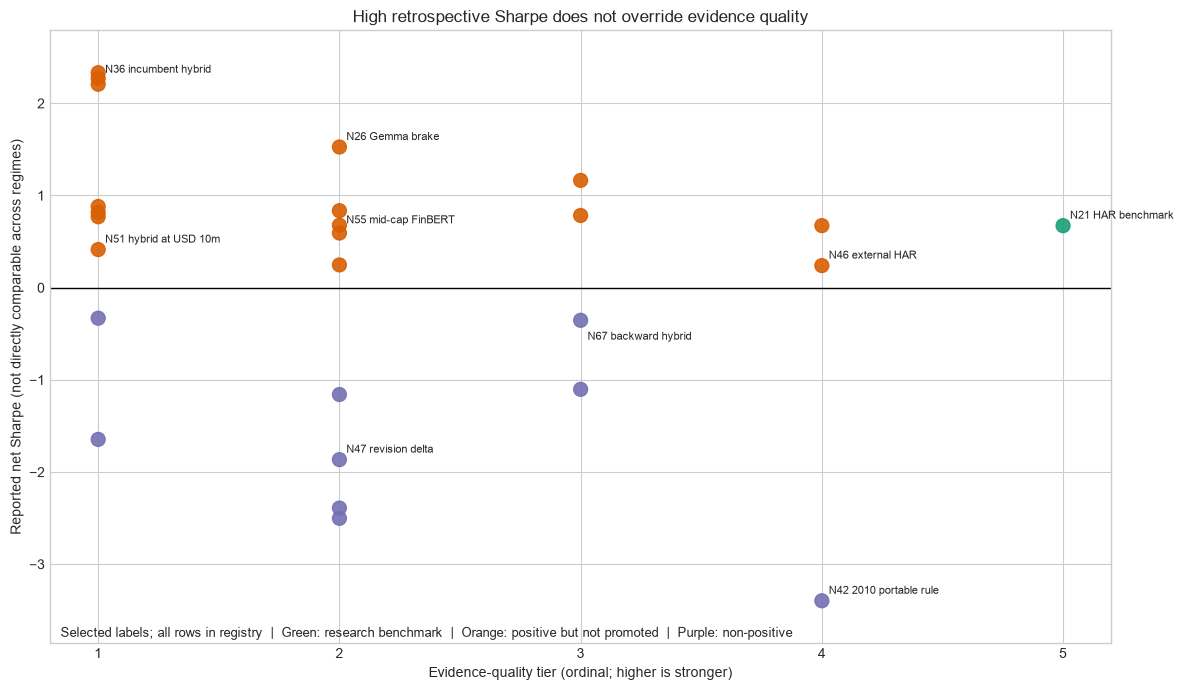

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = np.where(registry["decision_eligible"], "#1b9e77", np.where(registry["net_sharpe"] > 0, "#d95f02", "#7570b3"))
ax.scatter(registry["evidence_score"], registry["net_sharpe"], s=100, c=colors, alpha=0.9)
label_offsets = {
    (36, "Capped LSEG/Gemma hybrid"): (5, 4),
    (55, "Sparse mid-cap FinBERT event rule"): (5, 7),
    (67, "Unchanged hybrid backward replay"): (5, -14),
}
short_labels = {
    (21, "Sentiment-free HAR target"): "N21 HAR benchmark",
    (26, "Gemma exact-negative firm brake"): "N26 Gemma brake",
    (36, "Capped LSEG/Gemma hybrid"): "N36 incumbent hybrid",
    (42, "Portable continuous rule"): "N42 2010 portable rule",
    (46, "Frozen HAR target"): "N46 external HAR",
    (47, "Gemma story-revision delta"): "N47 revision delta",
    (51, "LSEG/Gemma hybrid at USD 10m"): "N51 hybrid at USD 10m",
    (55, "Sparse mid-cap FinBERT event rule"): "N55 mid-cap FinBERT",
    (67, "Unchanged hybrid backward replay"): "N67 backward hybrid",
}
for _, row in registry.iterrows():
    key = (int(row["notebook"]), row["strategy"])
    if key not in short_labels:
        continue
    ax.annotate(
        short_labels[key],
        (row["evidence_score"], row["net_sharpe"]),
        xytext=label_offsets.get(key, (5, 5)),
        textcoords="offset points", fontsize=8,
    )
ax.axhline(0, color="black", lw=1)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Evidence-quality tier (ordinal; higher is stronger)")
ax.set_ylabel("Reported net Sharpe (not directly comparable across regimes)")
ax.set_title("High retrospective Sharpe does not override evidence quality")
ax.margins(y=0.08)
ax.text(
    0.01, 0.01,
    "Selected labels; all rows in registry  |  Green: research benchmark  |  Orange: positive but not promoted  |  Purple: non-positive",
    transform=ax.transAxes, fontsize=9,
)
fig.tight_layout()
fig.savefig(OUTPUT / "evidence_quality_vs_net_sharpe.png", dpi=180, bbox_inches="tight")
plt.show()

## Paired sentiment/construction scorecard

The return estimand is always challenger minus its local base. Downside rows preserve
the sign convention used in each source, but `downside_improves` translates them to one
common interpretation. Notebook 50 is a same-sentiment allocation comparison rather than
a sentiment increment. These tests overlap in dates and strategy construction, so their
p-values are **not** combined into a meta-analysis.

In [5]:
n21_inf = tables["n21_inference"]
n24_inf = tables["n24_inference"]
n25_inf = tables["n25_inference"]
n26_inf = tables["n26_inference"]
n27_inf = tables["n27_inference"]
n46_inf = tables["n46_inference"]
n47_inf = tables["n47_inference"]
n48_inf = tables["n48_inference"]
n49_inf = tables["n49_inference"]
n50_inf = tables["n50_inference"]


def overlay_row(
    label: str,
    regime: str,
    challenger_sharpe: float,
    base_sharpe: float,
    mean: float,
    low: float,
    high: float,
    p_return: float,
    downside_p: float,
    downside_improves: bool,
    temporal_stable: bool,
    multiplicity: str,
) -> dict:
    return {
        "comparison": label,
        "regime": regime,
        "delta_net_sharpe": challenger_sharpe - base_sharpe,
        "return_difference_bps_session": 10_000 * mean,
        "return_ci_low_bps_session": 10_000 * low,
        "return_ci_high_bps_session": 10_000 * high,
        "return_p_two_sided": p_return,
        "return_ci_excludes_zero": bool(low > 0),
        "downside_improves": bool(downside_improves),
        "downside_p_two_sided": downside_p,
        "temporal_stable": bool(temporal_stable),
        "multiplicity": multiplicity,
    }


n21_ret = one(n21_inf, estimand="sentiment minus control net return")
n21_down = one(n21_inf, estimand="control minus sentiment downside squared return")
n24_ret = one(n24_inf, estimand="HAR sentiment minus HAR net return")
n24_down = one(n24_inf, estimand="HAR minus HAR sentiment downside squared return")
n25_ret = one(n25_inf, estimand="walk-forward HAR sentiment minus HAR net return")
n25_down = one(n25_inf, estimand="HAR minus sentiment downside squared return")
n26_ret = one(n26_inf, period="full", outcome="net_return")
n26_down = one(n26_inf, period="full", outcome="downside_sq")
n27_pre_ret = one(n27_inf, era="pre_2020", comparator="har_base", outcome="net_return")
n27_pre_down = one(n27_inf, era="pre_2020", comparator="har_base", outcome="downside_sq")
n27_eval_ret = one(n27_inf, era="evaluation", comparator="har_base", outcome="net_return")
n27_eval_down = one(n27_inf, era="evaluation", comparator="har_base", outcome="downside_sq")
n46_ret = one(
    n46_inf,
    comparison="gemma_overlay_vs_frozen_har",
    estimand="challenger minus baseline net return",
)
n46_down = one(
    n46_inf,
    comparison="gemma_overlay_vs_frozen_har",
    estimand="baseline minus challenger downside squared return",
)
n47_level_comparison = one(
    n47_inf,
    comparison="revision_delta_minus_matched_latest_level",
)
n48_event_comparison = one(
    n48_inf,
    comparison="persistent_state_minus_one_session_event",
)
n49_revision_comparison = one(
    n49_inf,
    comparison="strict_sign_flip_minus_revision_delta",
)
n50_equal_comparison = one(
    n50_inf,
    comparison="inverse_volatility_minus_equal_weight",
)

n25_base = one(tables["n25_results"], arm="walkforward_har")
n26_base = one(tables["n26_results"], period="full", arm="baseline")
n27_pre_cap = one(tables["n27_results"], era="pre_2020", arm="absolute_cap")
n27_pre_base = one(tables["n27_results"], era="pre_2020", arm="har_base")
n27_eval_base = one(tables["n27_results"], era="evaluation", arm="har_base")

overlays = pd.DataFrame(
    [
        overlay_row(
            "N21 sentiment variance feature", "FNSPID 2020–2023", n21_sent.sharpe_net, n21_har.sharpe_net,
            n21_ret["mean"], n21_ret["ci_low"], n21_ret["ci_high"], n21_ret["p_two_sided"],
            n21_down["p_two_sided"], False, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N24 HAR × sentiment", "FNSPID 2020–2023", n24_product.sharpe_net, n21_har.sharpe_net,
            n24_ret["mean"], n24_ret["ci_low"], n24_ret["ci_high"], n24_ret["p_two_sided"],
            n24_down["p_two_sided"], True, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N25 walk-forward HAR × sentiment", "FNSPID 2013–2019", n25_product.sharpe_net, n25_base.sharpe_net,
            n25_ret["mean"], n25_ret["ci_low"], n25_ret["ci_high"], n25_ret["p_two_sided"],
            n25_down["p_two_sided"], True, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N26 Gemma firm brake", "LSEG 2025–2026", n26_brake.sharpe_net, n26_base.sharpe_net,
            n26_ret["mean_difference"], n26_ret["ci_low"], n26_ret["ci_high"], n26_ret["p_two_sided"],
            n26_down["p_two_sided"], bool(n26_down["bh_reject_q05"]), True, "BH across return and downside",
        ),
        overlay_row(
            "N27 absolute cap", "FNSPID 2013–2019", n27_pre_cap.sharpe_net, n27_pre_base.sharpe_net,
            n27_pre_ret["mean"], n27_pre_ret["ci_low"], n27_pre_ret["ci_high"], n27_pre_ret["p_two_sided"],
            n27_pre_down["p_two_sided"], bool(n27_pre_down["bh_reject_q05"]), True,
            "BH across four operator comparisons per outcome",
        ),
        overlay_row(
            "N27 absolute cap", "FNSPID 2020–2023", n27_cap.sharpe_net, n27_eval_base.sharpe_net,
            n27_eval_ret["mean"], n27_eval_ret["ci_low"], n27_eval_ret["ci_high"], n27_eval_ret["p_two_sided"],
            n27_eval_down["p_two_sided"], bool(n27_eval_down["bh_reject_q05"]), True,
            "BH across four operator comparisons per outcome",
        ),
        overlay_row(
            "N46 HAR × Gemma breadth", "LSEG index 2025–2026", n46_overlay.sharpe_net, n46_har.sharpe_net,
            n46_ret["mean"], n46_ret["ci_low"], n46_ret["ci_high"], n46_ret["p_two_sided"],
            n46_down["p_two_sided"], bool(n46_down["bh_reject_q05"]), True,
            "BH across return and downside; deterministic breadth composition",
        ),
        overlay_row(
            "N47 revision delta vs latest level", "LSEG 2025–2026",
            n47_revision.sharpe_net, n47_level.sharpe_net,
            n47_level_comparison["mean_difference"], n47_level_comparison["ci_low"],
            n47_level_comparison["ci_high"], n47_level_comparison["p_two_sided"],
            np.nan, False, False,
            "BH across revision delta versus cash and matched latest level",
        ),
        overlay_row(
            "N48 persistent revision state", "LSEG 2025–2026",
            n48_state.sharpe_net, n48_event.sharpe_net,
            n48_event_comparison["mean_difference"], n48_event_comparison["ci_low"],
            n48_event_comparison["ci_high"], n48_event_comparison["p_two_sided"],
            np.nan, False, False,
            "BH across persistent state versus cash and one-session event",
        ),
        overlay_row(
            "N49 strict revision sign flips", "LSEG 2025–2026",
            n49_flip.sharpe_net, n47_revision.sharpe_net,
            n49_revision_comparison["mean_difference"], n49_revision_comparison["ci_low"],
            n49_revision_comparison["ci_high"], n49_revision_comparison["p_two_sided"],
            np.nan, False, False,
            "BH across strict sign flips versus cash and broad revision delta",
        ),
        overlay_row(
            "N50 inverse volatility vs equal weight", "LSEG 2025–2026",
            n50_risk.sharpe_net, n50_equal.sharpe_net,
            n50_equal_comparison["mean_difference"], n50_equal_comparison["ci_low"],
            n50_equal_comparison["ci_high"], n50_equal_comparison["p_two_sided"],
            np.nan, False, True,
            "BH across inverse-volatility hybrid versus cash and equal-weight hybrid",
        ),
        overlay_row(
            "N64 market residual vs incumbent", "LSEG 2025–2026",
            n64_market.sharpe_net, n36_hybrid.sharpe_net,
            n64_market_incumbent["mean_difference"], n64_market_incumbent["ci_low"],
            n64_market_incumbent["ci_high"], n64_market_incumbent["p_two_sided"],
            np.nan, False, bool(n64_market_class["both_half_means_positive"]),
            "BH across two cash and two incumbent comparisons; separate two-alpha factor family",
        ),
        overlay_row(
            "N64 sector residual vs incumbent", "LSEG 2025–2026",
            n64_sector.sharpe_net, n36_hybrid.sharpe_net,
            n64_sector_incumbent["mean_difference"], n64_sector_incumbent["ci_low"],
            n64_sector_incumbent["ci_high"], n64_sector_incumbent["p_two_sided"],
            np.nan, False, bool(n64_sector_class["both_half_means_positive"]),
            "BH across two cash and two incumbent comparisons; separate two-alpha factor family",
        ),
        overlay_row(
            "N65 Gemma specificity filter vs cash", "LSEG 2025–2026",
            n65_filtered.sharpe_net, 0.0,
            n65_cash["mean_difference"], n65_cash["ci_low"],
            n65_cash["ci_high"], n65_cash["p_two_sided"],
            np.nan, False, bool(n65_class["both_half_means_positive"]),
            "BH across cash and incumbent comparisons; separate one-alpha factor test",
        ),
        overlay_row(
            "N65 Gemma specificity filter vs incumbent", "LSEG 2025–2026",
            n65_filtered.sharpe_net, n36_hybrid.sharpe_net,
            n65_incumbent["mean_difference"], n65_incumbent["ci_low"],
            n65_incumbent["ci_high"], n65_incumbent["p_two_sided"],
            np.nan, False, bool(n65_class["both_half_means_positive"]),
            "BH across cash and incumbent comparisons; separate one-alpha factor test",
        ),
        overlay_row(
            "N67 unchanged backward hybrid vs cash", "LSEG 2024–2025",
            n67_backward.sharpe_net, 0.0,
            n67_backward_cash["mean_difference"], n67_backward_cash["ci_low"],
            n67_backward_cash["ci_high"], n67_backward_cash["p_two_sided"],
            np.nan, False, bool(n67_backward_halves["sharpe_net"].gt(0).all()),
            "single frozen cash test in the post-drift-stop earlier-time sensitivity",
        ),
        overlay_row(
            "N70 continuous rule backward vs cash", "LSEG 2024–2025",
            n70_backward.sharpe_net, 0.0,
            n70_backward_cash["mean_difference"], n70_backward_cash["ci_low"],
            n70_backward_cash["ci_high"], n70_backward_cash["p_two_sided"],
            np.nan, False, bool(n70_backward_halves["sharpe_net"].gt(0).all()),
            "BH across the two frozen source-block cash tests",
        ),
        overlay_row(
            "N70 continuous rule opened-window vs cash", "LSEG 2025–2026",
            n70_opened.sharpe_net, 0.0,
            n70_opened_cash["mean_difference"], n70_opened_cash["ci_low"],
            n70_opened_cash["ci_high"], n70_opened_cash["p_two_sided"],
            np.nan, False, bool(n70_opened_halves["sharpe_net"].gt(0).all()),
            "BH across the two frozen source-block cash tests",
        ),
    ]
)

overlays["promotion_pass"] = (
    overlays["return_ci_excludes_zero"] & overlays["downside_improves"] & overlays["temporal_stable"]
)
assert int(overlays["return_ci_excludes_zero"].sum()) == 1
assert not overlays["promotion_pass"].any()
overlays.to_csv(OUTPUT / "sentiment_overlay_scorecard.csv", index=False)

display(
    overlays[
        [
            "comparison",
            "regime",
            "delta_net_sharpe",
            "return_difference_bps_session",
            "return_ci_low_bps_session",
            "return_ci_high_bps_session",
            "downside_improves",
            "downside_p_two_sided",
            "promotion_pass",
        ]
    ].style.format(
        {
            "delta_net_sharpe": "{:+.3f}",
            "return_difference_bps_session": "{:+.3f}",
            "return_ci_low_bps_session": "{:+.3f}",
            "return_ci_high_bps_session": "{:+.3f}",
            "downside_p_two_sided": "{:.4f}",
        }
    )
)

,comparison,regime,delta_net_sharpe,return_difference_bps_session,return_ci_low_bps_session,return_ci_high_bps_session,downside_improves,downside_p_two_sided,promotion_pass
0,N21 sentiment variance feature,FNSPID 2020–2023,+0.001,+0.045,-0.282,+0.371,False,0.0810,False
1,N24 HAR × sentiment,FNSPID 2020–2023,+0.162,+0.366,-0.996,+1.930,True,0.0148,False
2,N25 walk-forward HAR × sentiment,FNSPID 2013–2019,+0.050,-0.134,-0.987,+0.736,True,0.0052,False
3,N26 Gemma firm brake,LSEG 2025–2026,+0.054,+0.148,-0.405,+0.678,True,0.0088,False
4,N27 absolute cap,FNSPID 2013–2019,+0.062,-0.062,-0.815,+0.729,True,0.0064,False
5,N27 absolute cap,FNSPID 2020–2023,+0.097,+0.229,-0.631,+1.125,True,0.0030,False
6,N46 HAR × Gemma breadth,LSEG index 2025–2026,+0.007,+0.013,-0.156,+0.188,True,0.0122,False
7,N47 revision delta vs latest level,LSEG 2025–2026,+3.139,+15.620,+2.683,+28.725,False,nan,False
8,N48 persistent revision state,LSEG 2025–2026,+1.534,+7.498,-0.006,+15.165,False,nan,False
9,N49 strict revision sign flips,LSEG 2025–2026,+0.220,+3.902,-5.289,+13.007,False,nan,False


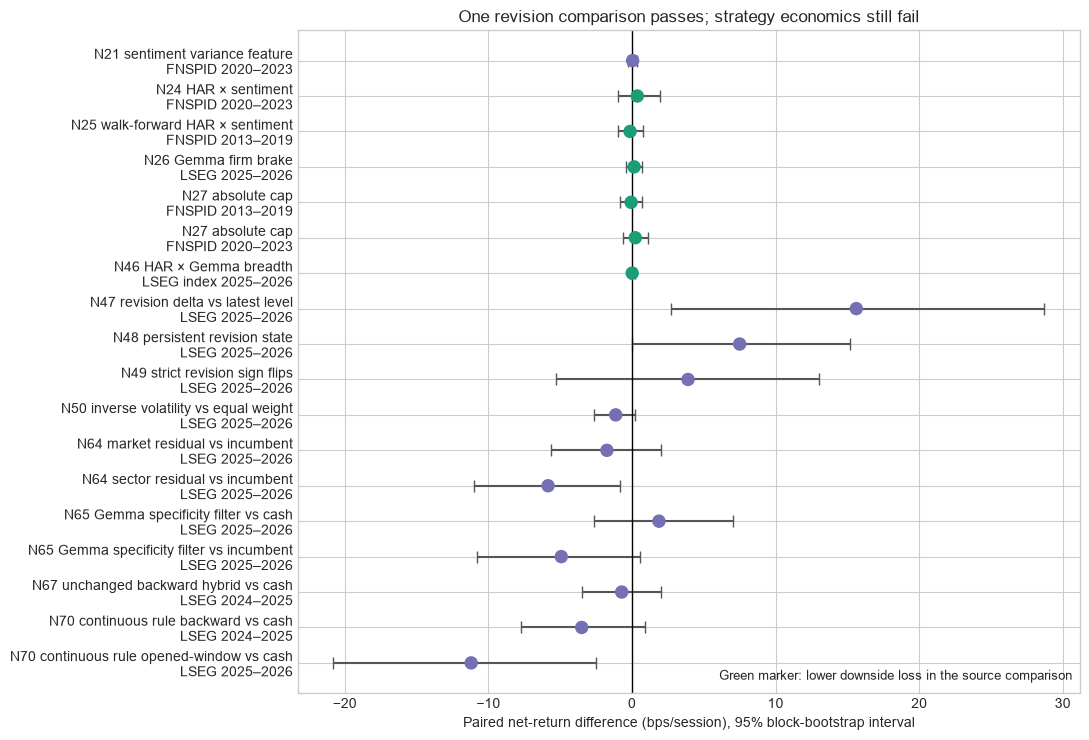

In [6]:
fig, ax = plt.subplots(figsize=(11, 7.5))
y = np.arange(len(overlays))
means = overlays["return_difference_bps_session"].to_numpy()
lows = overlays["return_ci_low_bps_session"].to_numpy()
highs = overlays["return_ci_high_bps_session"].to_numpy()
point_colors = np.where(overlays["downside_improves"], "#1b9e77", "#7570b3")
ax.errorbar(means, y, xerr=[means - lows, highs - means], fmt="none", ecolor="#555555", capsize=4, lw=1.5)
ax.scatter(means, y, c=point_colors, s=75, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(
    y,
    [
        f"{comparison}\n{regime}"
        for comparison, regime in zip(
            overlays["comparison"], overlays["regime"], strict=True
        )
    ],
)
ax.invert_yaxis()
ax.set_xlabel("Paired net-return difference (bps/session), 95% block-bootstrap interval")
ax.set_title("One revision comparison passes; strategy economics still fail")
ax.text(
    0.99, 0.02, "Green marker: lower downside loss in the source comparison",
    transform=ax.transAxes, ha="right", fontsize=9,
)
fig.tight_layout()
fig.savefig(OUTPUT / "paired_sentiment_overlay_returns.png", dpi=180, bbox_inches="tight")
plt.show()

## Cross-regime continuous-rule stress test

Notebook 39 chose mean-continuous aggregation without opening returns. The same
construction then produced positive gross performance in the later FNSPID evaluation
block, but weak development economics, negative 2010 performance, and negative direct
LSEG performance. Notebook 70 now repeats that LSEG check over both same-source
time blocks with the frozen continuous rule. This is evidence that **measurement
portability is not economic portability**.

In [7]:
n40_dev = one(tables["n40_results"], split="development", strategy="adaptive_dispersion")
n43_all = one(tables["n43_results"], strategy="all_headlines")


def transfer_row(label: str, row: pd.Series) -> dict:
    return {
        "regime": label,
        "gross_sharpe": float(row["sharpe_gross"]),
        "net_sharpe": float(row["sharpe_net"]),
        "gross_total_return": float(row["total_return_gross"]),
        "net_total_return": float(row["total_return_net"]),
        "breakeven_bps_per_side": float(row["breakeven_bps_per_side"]),
    }


transfer = pd.DataFrame(
    [
        transfer_row("FNSPID development", n40_dev),
        transfer_row("FNSPID evaluation", n40_eval),
        transfer_row("FNSPID 2010", n42_adaptive),
        transfer_row("LSEG all headlines", n43_all),
        transfer_row("LSEG first release", n43_filtered),
        transfer_row("LSEG 2024–2025 continuous", n70_backward),
        transfer_row("LSEG 2025–2026 continuous", n70_opened),
    ]
)
transfer["gross_positive"] = transfer["gross_sharpe"] > 0
transfer["net_positive"] = transfer["net_sharpe"] > 0
assert not transfer["net_positive"].any()
assert (transfer["gross_positive"].sum() == 3)
transfer.to_csv(OUTPUT / "continuous_rule_cross_regime.csv", index=False)
display(transfer.style.format({
    "gross_sharpe": "{:+.3f}", "net_sharpe": "{:+.3f}",
    "gross_total_return": "{:+.1%}", "net_total_return": "{:+.1%}",
    "breakeven_bps_per_side": "{:+.3f}",
}))

,regime,gross_sharpe,net_sharpe,gross_total_return,net_total_return,breakeven_bps_per_side,gross_positive,net_positive
0,FNSPID development,+0.187,-3.215,+5.5%,-65.5%,+0.532,True,False
1,FNSPID evaluation,+1.056,-1.103,+27.3%,-23.3%,+4.904,True,False
2,FNSPID 2010,-1.141,-3.397,-5.5%,-15.9%,-4.802,False,False
3,LSEG all headlines,-1.737,-2.635,-12.3%,-18.1%,-18.625,False,False
4,LSEG first release,-1.473,-2.502,-10.3%,-16.8%,-13.908,False,False
5,LSEG 2024–2025 continuous,+0.308,-1.159,+3.8%,-15.2%,+2.090,True,False
6,LSEG 2025–2026 continuous,-1.409,-2.391,-10.8%,-17.5%,-14.024,False,False


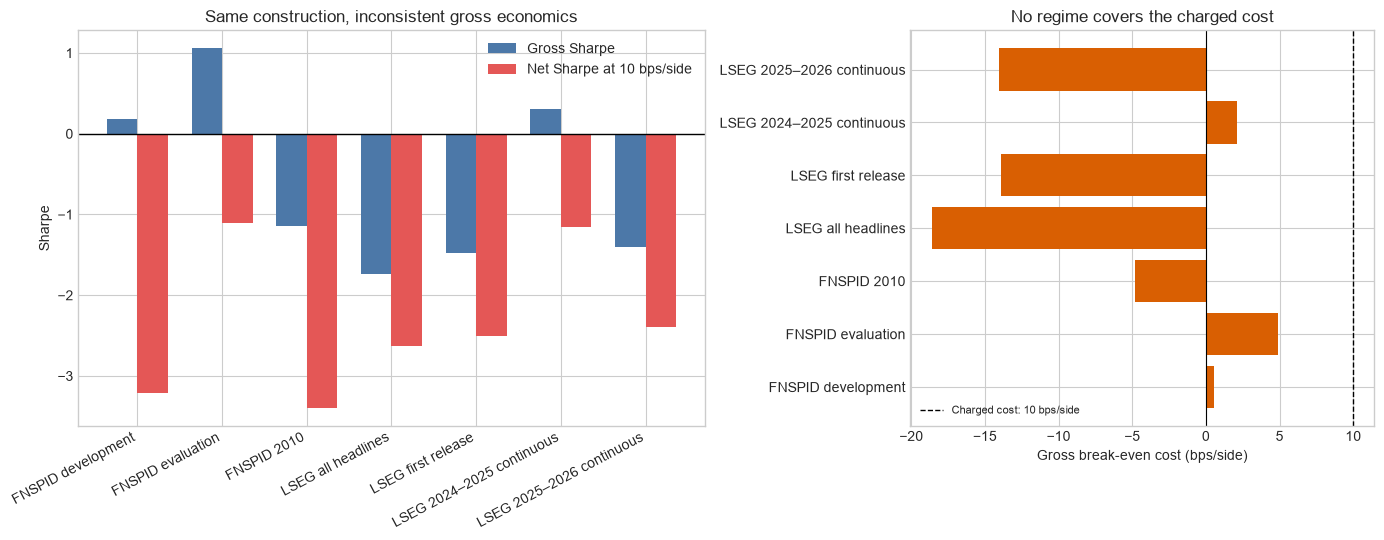

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
x = np.arange(len(transfer))
width = 0.36
axes[0].bar(x - width / 2, transfer["gross_sharpe"], width, label="Gross Sharpe", color="#4c78a8")
axes[0].bar(x + width / 2, transfer["net_sharpe"], width, label="Net Sharpe at 10 bps/side", color="#e45756")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x, transfer["regime"], rotation=28, ha="right")
axes[0].set_ylabel("Sharpe")
axes[0].set_title("Same construction, inconsistent gross economics")
axes[0].legend()

be_colors = np.where(transfer["breakeven_bps_per_side"] >= 10, "#1b9e77", "#d95f02")
axes[1].barh(transfer["regime"], transfer["breakeven_bps_per_side"], color=be_colors)
axes[1].axvline(10, color="black", ls="--", lw=1, label="Charged cost: 10 bps/side")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Gross break-even cost (bps/side)")
axes[1].set_title("No regime covers the charged cost")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "continuous_rule_cross_regime.png", dpi=180, bbox_inches="tight")
plt.show()

## Decision

In [9]:
n62_manifest = tables["n62_manifest"]
n63_manifest = tables["n63_manifest"]
n64_manifest = tables["n64_manifest"]

decision = {
    "working_strategy_base": "sentiment-free HAR 10% volatility target as research benchmark only",
    "deployment_qualified_strategy_base": None,
    "base_notebook": 21,
    "base_net_sharpe": float(n21_har["sharpe_net"]),
    "base_net_total_return": float(n21_har["total_return_net"]),
    "base_max_drawdown": float(n21_har["max_drawdown"]),
    "external_time_base_notebook": 46,
    "external_time_base_gate": bool(tables["n46_gates"].iloc[0]["external_time_base_gate"]),
    "external_time_har_net_sharpe": float(n46_har["sharpe_net"]),
    "external_time_constant_net_sharpe": float(n46_constant["sharpe_net"]),
    "external_time_har_total_return": float(n46_har["total_return_net"]),
    "external_time_har_max_drawdown": float(n46_har["max_drawdown"]),
    "historical_lseg_comparator_notebook": 55,
    "historical_lseg_comparator_role": n55_manifest["decision"]["role"],
    "historical_lseg_comparator_net_sharpe": float(n55_registry_row["sharpe_net"]),
    "historical_lseg_comparator_net_return": float(n55_registry_row["total_return_net"]),
    "historical_lseg_comparator_breakeven_bps": float(n55_registry_row["breakeven_bps_per_side"]),
    "historical_lseg_comparator_ci_low_bps": float(n55_manifest["decision"]["evaluation_ci_low_bps_per_session"]),
    "historical_lseg_comparator_ci_high_bps": float(n55_manifest["decision"]["evaluation_ci_high_bps_per_session"]),
    "historical_lseg_comparator_max_name_weight": float(n55_manifest["decision"]["maximum_observed_name_weight"]),
    "historical_lseg_comparator_legacy_gate": bool(n55_manifest["decision"]["legacy_local_gate"]),
    "local_lseg_run_directories": int(n56_manifest["decision"]["run_directories"]),
    "local_lseg_exact_metrics_payloads": int(n56_manifest["decision"]["exact_metrics_payloads"]),
    "local_lseg_declared_families": int(n56_manifest["decision"]["declared_strategy_families"]),
    "local_lseg_passing_families": int(n56_manifest["decision"]["primary_families_passing_descriptive_floor"]),
    "local_lseg_only_passing_family": n56_manifest["decision"]["only_passing_family"],
    "local_lseg_distinct_positive_base_omitted": bool(n56_manifest["decision"]["another_distinct_positive_covered_base_omitted"]),
    "local_lseg_underpowered_eval_sharpe": float(n56_magnitude["evaluation_net_sharpe"]),
    "local_lseg_underpowered_eval_active_sessions": int(n56_magnitude["evaluation_active_sessions"]),
    "local_lseg_underpowered_dev_sharpe": float(n56_magnitude["development_net_sharpe"]),
    "prospective_strategy_candidate_notebook": 36,
    "prospective_strategy_candidate": n57_manifest["decision"]["prospective_primary"],
    "prospective_strategy_candidate_gross_sharpe": float(n57_decision_row["primary_gross_sharpe"]),
    "prospective_strategy_candidate_net_sharpe_10bps": float(n57_decision_row["primary_net_sharpe_at_10bps"]),
    "prospective_strategy_candidate_net_sharpe_5bps": float(n57_decision_row["primary_net_sharpe_at_5bps"]),
    "prospective_strategy_candidate_breakeven_bps": float(n57_decision_row["primary_break_even_bps_per_side"]),
    "prospective_strategy_candidate_factor_alpha_low_bps": float(n57_decision_row["primary_sector_factor_ci_low_bps_session"]),
    "prospective_strategy_candidate_factor_alpha_high_bps": float(n57_decision_row["primary_sector_factor_ci_high_bps_session"]),
    "prospective_strategy_candidate_y1_sharpe_1m": float(n57_decision_row["impact_y1_net_sharpe_1m"]),
    "prospective_strategy_candidate_y1_sharpe_10m": float(n57_decision_row["impact_y1_net_sharpe_10m"]),
    "prospective_strategy_candidate_y1_sharpe_25m": float(n57_decision_row["impact_y1_net_sharpe_25m"]),
    "prospective_strategy_candidate_validated_alpha": bool(n57_manifest["decision"]["validated_alpha"]),
    "prospective_strategy_candidate_deployment_qualified": bool(n57_manifest["decision"]["deployment_qualified"]),
    "backward_hybrid_notebook": 67,
    "backward_hybrid_complete_sessions": int(n67_backward["complete_sessions"]),
    "backward_hybrid_incomplete_cash_sessions": int(n67_backward["incomplete_cash_sessions"]),
    "backward_hybrid_active_sessions": int(n67_backward["active_sessions"]),
    "backward_hybrid_gross_sharpe": float(n67_backward["sharpe_gross"]),
    "backward_hybrid_net_sharpe": float(n67_backward["sharpe_net"]),
    "backward_hybrid_net_return": float(n67_backward["total_return_net"]),
    "backward_hybrid_breakeven_bps": float(n67_backward["breakeven_bps_per_side"]),
    "backward_hybrid_cash_ci_low_bps": float(n67_backward_cash["ci_low"] * 10_000),
    "backward_hybrid_cash_ci_high_bps": float(n67_backward_cash["ci_high"] * 10_000),
    "backward_hybrid_cash_p": float(n67_backward_cash["p_two_sided"]),
    "backward_hybrid_factor_alpha_bps": float(n67_backward_factor["alpha_bps_session"]),
    "backward_hybrid_factor_ci_low_bps": float(n67_backward_factor["alpha_ci_low_bps_session"]),
    "backward_hybrid_factor_ci_high_bps": float(n67_backward_factor["alpha_ci_high_bps_session"]),
    "backward_hybrid_factor_p": float(n67_backward_factor["alpha_p_two_sided_hac5"]),
    "backward_hybrid_positive_company_replays": int(n67_manifest["dependence"]["positive_company_returns"]),
    "backward_hybrid_company_replays": int(n67_manifest["dependence"]["company_replays"]),
    "backward_hybrid_positive_sector_replays": int(n67_manifest["dependence"]["positive_sector_returns"]),
    "backward_hybrid_sector_replays": int(n67_manifest["dependence"]["sector_replays"]),
    "joined_hybrid_sessions": int(n67_joined["n_sessions"]),
    "joined_hybrid_gross_sharpe": float(n67_joined["sharpe_gross"]),
    "joined_hybrid_net_sharpe": float(n67_joined["sharpe_net"]),
    "joined_hybrid_net_return": float(n67_joined["total_return_net"]),
    "joined_hybrid_unique_headlines": int(n67_manifest["join"]["joined_unique_headlines"]),
    "backward_hybrid_drift_gate_passed": not bool(
        n67_manifest["claim_boundary"]["original_drift_gate_remains_failed"]
    ),
    "backward_hybrid_all_return_gates_passed": bool(
        n67_manifest["gates"]["all_return_gates_pass_excluding_drift"]
    ),
    "continuous_long_window_notebook": 70,
    "continuous_backward_gross_sharpe": float(n70_backward["sharpe_gross"]),
    "continuous_backward_net_sharpe": float(n70_backward["sharpe_net"]),
    "continuous_backward_net_return": float(n70_backward["total_return_net"]),
    "continuous_backward_breakeven_bps": float(n70_backward["breakeven_bps_per_side"]),
    "continuous_backward_cash_ci_low_bps": float(n70_backward_cash["ci_low"] * 10_000),
    "continuous_backward_cash_ci_high_bps": float(n70_backward_cash["ci_high"] * 10_000),
    "continuous_opened_gross_sharpe": float(n70_opened["sharpe_gross"]),
    "continuous_opened_net_sharpe": float(n70_opened["sharpe_net"]),
    "continuous_opened_net_return": float(n70_opened["total_return_net"]),
    "continuous_opened_breakeven_bps": float(n70_opened["breakeven_bps_per_side"]),
    "continuous_opened_cash_ci_low_bps": float(n70_opened_cash["ci_low"] * 10_000),
    "continuous_opened_cash_ci_high_bps": float(n70_opened_cash["ci_high"] * 10_000),
    "continuous_opened_cash_bh_q": float(n70_opened_cash["q_bh"]),
    "continuous_opened_factor_ci_low_bps": float(n70_opened_factor["alpha_ci_low_bps_session"]),
    "continuous_opened_factor_ci_high_bps": float(n70_opened_factor["alpha_ci_high_bps_session"]),
    "continuous_joined_net_sharpe": float(n70_joined["sharpe_net"]),
    "continuous_joined_net_return": float(n70_joined["total_return_net"]),
    "continuous_gemma_duplicate_spearman": float(n70_gemma_reproducibility["spearman"]),
    "continuous_gemma_duplicate_exact_equality": float(n70_gemma_reproducibility["exact_equality"]),
    "continuous_cross_time_stability_gate": bool(
        n70_manifest["gates"]["cross_time_stability_gate"]
    ),
    "sentiment_strategy_promoted": False,
    "sentiment_overlay_return_intervals_excluding_zero": int(overlays["return_ci_excludes_zero"].sum()),
    "sentiment_overlay_comparisons": int(len(overlays)),
    "downside_improvement_comparisons": int(overlays["downside_improves"].sum()),
    "continuous_rule_net_positive_regimes": int(transfer["net_positive"].sum()),
    "continuous_rule_regimes": int(len(transfer)),
    "revision_delta_gross_sharpe": float(n47_revision["sharpe_gross"]),
    "revision_delta_net_sharpe": float(n47_revision["sharpe_net"]),
    "revision_delta_breakeven_bps": float(n47_revision["breakeven_bps_per_side"]),
    "revision_delta_minus_level_bps": float(
        n47_level_comparison["mean_difference"] * 10_000
    ),
    "revision_delta_minus_level_ci_low_bps": float(
        n47_level_comparison["ci_low"] * 10_000
    ),
    "revision_delta_minus_level_ci_high_bps": float(
        n47_level_comparison["ci_high"] * 10_000
    ),
    "persistent_state_net_sharpe": float(n48_state["sharpe_net"]),
    "persistent_state_breakeven_bps": float(n48_state["breakeven_bps_per_side"]),
    "strict_sign_flip_gross_sharpe": float(n49_flip["sharpe_gross"]),
    "strict_sign_flip_net_sharpe": float(n49_flip["sharpe_net"]),
    "strict_sign_flip_breakeven_bps": float(n49_flip["breakeven_bps_per_side"]),
    "strict_sign_flip_minus_revision_bps": float(
        n49_revision_comparison["mean_difference"] * 10_000
    ),
    "strict_sign_flip_minus_revision_ci_low_bps": float(
        n49_revision_comparison["ci_low"] * 10_000
    ),
    "strict_sign_flip_minus_revision_ci_high_bps": float(
        n49_revision_comparison["ci_high"] * 10_000
    ),
    "inverse_volatility_gross_sharpe": float(n50_risk["sharpe_gross"]),
    "inverse_volatility_net_sharpe": float(n50_risk["sharpe_net"]),
    "inverse_volatility_net_return": float(n50_risk["total_return_net"]),
    "inverse_volatility_ann_vol_net": float(n50_risk["ann_vol_net"]),
    "inverse_volatility_turnover": float(n50_risk["total_turnover"]),
    "inverse_volatility_minus_equal_bps": float(
        n50_equal_comparison["mean_difference"] * 10_000
    ),
    "inverse_volatility_minus_equal_ci_low_bps": float(
        n50_equal_comparison["ci_low"] * 10_000
    ),
    "inverse_volatility_minus_equal_ci_high_bps": float(
        n50_equal_comparison["ci_high"] * 10_000
    ),
    "hybrid_capacity_aum_usd_primary_grid": float(
        tables["n51_gates"].iloc[0]["capacity_aum_usd_primary_grid"]
    ),
    "hybrid_capacity_one_million_net_sharpe": float(n51_primary_one["sharpe_net"]),
    "hybrid_capacity_one_million_net_return": float(n51_primary_one["total_return_net"]),
    "hybrid_capacity_one_million_max_participation": float(
        n51_primary_one["maximum_participation"]
    ),
    "hybrid_capacity_ten_million_net_sharpe": float(n51_primary_ten["sharpe_net"]),
    "hybrid_capacity_ten_million_net_return": float(n51_primary_ten["total_return_net"]),
    "hybrid_capacity_ten_million_max_participation": float(
        n51_primary_ten["maximum_participation"]
    ),
    "hybrid_capacity_twenty_five_million_net_sharpe": float(
        n51_primary_twenty_five["sharpe_net"]
    ),
    "hybrid_capacity_twenty_five_million_net_return": float(
        n51_primary_twenty_five["total_return_net"]
    ),
    "hybrid_capacity_twenty_five_million_breaching_orders": int(
        n51_primary_twenty_five["orders_over_participation_limit"]
    ),
    "hybrid_uncertainty_passing_grid_points": int(
        n58_manifest["decision"]["passing_grid_points"]
    ),
    "hybrid_uncertainty_capacity_aum_usd": n58_manifest["decision"]["uncertainty_aware_capacity_aum_usd"],
    "hybrid_uncertainty_one_million_mean_ci_low_bps": float(n58_one["bootstrap_mean_ci_low_bps_session"]),
    "hybrid_uncertainty_one_million_mean_ci_high_bps": float(n58_one["bootstrap_mean_ci_high_bps_session"]),
    "hybrid_uncertainty_one_million_probability_positive": float(n58_one["bootstrap_probability_terminal_positive"]),
    "hybrid_uncertainty_one_million_second_half_sharpe": float(n58_one["second_half_net_sharpe"]),
    "hybrid_uncertainty_ten_million_mean_ci_low_bps": float(n58_ten["bootstrap_mean_ci_low_bps_session"]),
    "hybrid_uncertainty_ten_million_mean_ci_high_bps": float(n58_ten["bootstrap_mean_ci_high_bps_session"]),
    "hybrid_uncertainty_ten_million_probability_positive": float(n58_ten["bootstrap_probability_terminal_positive"]),
    "hybrid_uncertainty_ten_million_second_half_sharpe": float(n58_ten["second_half_net_sharpe"]),
    "hybrid_intraday_mean_bps": float(n59_intraday["mean_bps_session"]),
    "hybrid_intraday_ci_low_bps": float(n59_intraday["ci_low_bps_session"]),
    "hybrid_intraday_ci_high_bps": float(n59_intraday["ci_high_bps_session"]),
    "hybrid_intraday_bh_q": float(n59_intraday["bh_q_value"]),
    "hybrid_overnight_mean_bps": float(n59_overnight["mean_bps_session"]),
    "hybrid_overnight_ci_low_bps": float(n59_overnight["ci_low_bps_session"]),
    "hybrid_overnight_ci_high_bps": float(n59_overnight["ci_high_bps_session"]),
    "hybrid_overnight_bh_q": float(n59_overnight["bh_q_value"]),
    "hybrid_long_share_of_gross_sum": float(n59_long["share_of_total_gross_sum"]),
    "hybrid_long_gross_sharpe": float(n59_long["sharpe_all_sessions"]),
    "hybrid_short_gross_sharpe": float(n59_short["sharpe_all_sessions"]),
    "hybrid_long_minus_market_bps": float(n60_market["mean_difference_bps_session"]),
    "hybrid_long_minus_market_ci_low_bps": float(n60_market["ci_low_bps_session"]),
    "hybrid_long_minus_market_ci_high_bps": float(n60_market["ci_high_bps_session"]),
    "hybrid_long_minus_market_bh_q": float(n60_market["bh_q_value"]),
    "hybrid_long_minus_sector_bps": float(n60_sector["mean_difference_bps_session"]),
    "hybrid_long_minus_sector_ci_low_bps": float(n60_sector["ci_low_bps_session"]),
    "hybrid_long_minus_sector_ci_high_bps": float(n60_sector["ci_high_bps_session"]),
    "hybrid_long_minus_sector_bh_q": float(n60_sector["bh_q_value"]),
    "hybrid_long_mechanism_result": "selected long beats both matched gross controls on the opened window",
    "hybrid_long_sector_intraday_difference_bps": float(n61_intraday["mean_difference_bps_session"]),
    "hybrid_long_sector_intraday_ci_low_bps": float(n61_intraday["ci_low_bps_session"]),
    "hybrid_long_sector_intraday_ci_high_bps": float(n61_intraday["ci_high_bps_session"]),
    "hybrid_long_sector_intraday_bh_q": float(n61_intraday["bh_q_value"]),
    "hybrid_long_sector_overnight_difference_bps": float(n61_overnight["mean_difference_bps_session"]),
    "hybrid_long_sector_overnight_ci_low_bps": float(n61_overnight["ci_low_bps_session"]),
    "hybrid_long_sector_overnight_ci_high_bps": float(n61_overnight["ci_high_bps_session"]),
    "hybrid_long_sector_overnight_bh_q": float(n61_overnight["bh_q_value"]),
    "hybrid_long_sector_overnight_second_half_bps": float(n61_overnight["second_half_mean_difference_bps_session"]),
    "hybrid_long_sector_component_result": "neither component passes; no exit or session component is promoted",
    "cash_flow_audit_status": n62_manifest["status"],
    "cash_flow_coder_a_complete_rows": int(n62_manifest["coding_progress"]["A"]["complete_rows"]),
    "cash_flow_coder_b_complete_rows": int(n62_manifest["coding_progress"]["B"]["complete_rows"]),
    "hybrid_characteristic_attribution_class": n63_manifest["decision"]["interpretation_class"],
    "hybrid_characteristic_explained_bps": float(n63_manifest["decision"]["characteristic_explained_bps_session"]),
    "hybrid_characteristic_residual_bps": float(n63_manifest["decision"]["adjusted_residual_bps_session"]),
    "hybrid_characteristic_residual_ci_low_bps": float(n63_manifest["decision"]["adjusted_residual_ci_low_bps_session"]),
    "hybrid_characteristic_residual_ci_high_bps": float(n63_manifest["decision"]["adjusted_residual_ci_high_bps_session"]),
    "hybrid_characteristic_residual_p": float(n63_manifest["decision"]["adjusted_residual_p_two_sided"]),
    "hybrid_market_residual_class": str(n64_market_class["classification"]),
    "hybrid_market_residual_net_sharpe": float(n64_market["sharpe_net"]),
    "hybrid_market_residual_net_return": float(n64_market["total_return_net"]),
    "hybrid_market_residual_max_drawdown": float(n64_market["max_drawdown"]),
    "hybrid_market_residual_total_turnover": float(n64_market["total_turnover"]),
    "hybrid_market_residual_breakeven_bps": float(n64_market["breakeven_bps_per_side"]),
    "hybrid_market_residual_cash_bps": float(n64_market_cash["mean_difference_bps_session"]),
    "hybrid_market_residual_cash_ci_low_bps": float(n64_market_cash["ci_low_bps_session"]),
    "hybrid_market_residual_cash_ci_high_bps": float(n64_market_cash["ci_high_bps_session"]),
    "hybrid_market_residual_cash_bh_q": float(n64_market_cash["bh_q_value"]),
    "hybrid_market_residual_factor_alpha_bps": float(n64_market_factor["alpha_bps_session"]),
    "hybrid_market_residual_factor_bh_q": float(n64_market_factor["bh_q_value"]),
    "hybrid_market_residual_minus_incumbent_bps": float(n64_market_incumbent["mean_difference_bps_session"]),
    "hybrid_market_residual_minus_incumbent_ci_low_bps": float(n64_market_incumbent["ci_low_bps_session"]),
    "hybrid_market_residual_minus_incumbent_ci_high_bps": float(n64_market_incumbent["ci_high_bps_session"]),
    "hybrid_sector_residual_class": str(n64_sector_class["classification"]),
    "hybrid_sector_residual_net_sharpe": float(n64_sector["sharpe_net"]),
    "hybrid_sector_residual_second_half_mean_bps": float(
        one(n64_halves, strategy="sector_residual", period="second_half")["mean_net_bps_session"]
    ),
    "hybrid_residual_any_retrospective_improvement": bool(
        n64_manifest["decision"]["any_retrospective_improvement"]
    ),
    "hybrid_specificity_filter_class": n65_manifest["decision"]["classification"],
    "hybrid_specificity_unfiltered_defined_firm_opens": int(
        n65_gemma_unfiltered["defined_strongest_event_firm_opens"]
    ),
    "hybrid_specificity_filtered_defined_firm_opens": int(
        n65_gemma_filtered["defined_strongest_event_firm_opens"]
    ),
    "hybrid_specificity_incumbent_active_sessions": int(
        one(n65_results, strategy="notebook36_incumbent")["active_sessions"]
    ),
    "hybrid_specificity_filtered_active_sessions": int(n65_filtered["active_sessions"]),
    "hybrid_specificity_filtered_gross_sharpe": float(n65_filtered["sharpe_gross"]),
    "hybrid_specificity_filtered_net_sharpe": float(n65_filtered["sharpe_net"]),
    "hybrid_specificity_filtered_net_return": float(n65_filtered["total_return_net"]),
    "hybrid_specificity_filtered_turnover": float(n65_filtered["total_turnover"]),
    "hybrid_specificity_filtered_breakeven_bps": float(
        n65_filtered["breakeven_bps_per_side"]
    ),
    "hybrid_specificity_cash_bps": float(n65_cash["mean_difference_bps_session"]),
    "hybrid_specificity_cash_ci_low_bps": float(n65_cash["ci_low_bps_session"]),
    "hybrid_specificity_cash_ci_high_bps": float(n65_cash["ci_high_bps_session"]),
    "hybrid_specificity_cash_bh_q": float(n65_cash["bh_q_value"]),
    "hybrid_specificity_minus_incumbent_bps": float(
        n65_incumbent["mean_difference_bps_session"]
    ),
    "hybrid_specificity_minus_incumbent_ci_low_bps": float(
        n65_incumbent["ci_low_bps_session"]
    ),
    "hybrid_specificity_minus_incumbent_ci_high_bps": float(
        n65_incumbent["ci_high_bps_session"]
    ),
    "hybrid_specificity_minus_incumbent_bh_q": float(n65_incumbent["bh_q_value"]),
    "hybrid_specificity_factor_alpha_bps": float(n65_factor["alpha_bps_session"]),
    "hybrid_specificity_factor_ci_low_bps": float(n65_factor["alpha_ci_low_bps_session"]),
    "hybrid_specificity_factor_ci_high_bps": float(n65_factor["alpha_ci_high_bps_session"]),
    "hybrid_specificity_factor_p": float(n65_factor["alpha_p_two_sided_hac5"]),
    "liquidity_sizing_input_gate": bool(n52_input["input_gate_pass"]),
    "liquidity_sizing_impact_proxy_change_fraction": float(
        n52_input["impact_proxy_change_fraction"]
    ),
    "liquidity_sizing_equal_target_turnover": float(
        n52_input["equal_target_l1_turnover"]
    ),
    "liquidity_sizing_optimized_target_turnover": float(
        n52_input["optimized_target_l1_turnover"]
    ),
    "liquidity_sizing_turnover_change_fraction": float(
        n52_input["target_turnover_change_fraction"]
    ),
    "liquidity_sizing_returns_constructed": bool(n52_input["returns_constructed"]),
    "prospective_batch_headlines": int(n53_coverage["headline_rows"]),
    "prospective_post_cutoff_headlines": int(
        n53_coverage["strictly_post_cutoff_headlines"]
    ),
    "prospective_pre_cutoff_headlines": int(n53_coverage["before_cutoff_headlines"]),
    "prospective_calendar_session_upper_bound": int(
        n54_calendar_gate["observed_or_upper_bound"]
    ),
    "prospective_required_calendar_sessions": int(n54_calendar_gate["required"]),
    "prospective_earliest_possible_120th_session": n54_manifest["population_gate"][
        "earliest_possible_required_session"
    ],
    "prospective_registered_batches": int(n54_summary["registered_batches"]),
    "prospective_eligible_unique_normalized_headlines": int(
        n54_summary["eligible_unique_normalized_headlines"]
    ),
    "prospective_normalization_request_reduction_fraction": float(
        n54_summary["normalization_request_reduction_pct"] / 100.0
    ),
    "prospective_planning_cost_at_reference_rate_usd": float(
        n54_summary["planning_cost_at_reference_rate_usd"]
    ),
    "prospective_scoring_launched": bool(
        n54_manifest["stop_controls"]["finbert_scoring_launched"]
        or n54_manifest["stop_controls"]["paid_external_gemma_scoring_launched"]
    ),
    "prospective_returns_loaded": bool(n54_manifest["stop_controls"]["returns_loaded"]),
    "lseg_gemma_role": "non-pooled measurement and mechanism evidence plus a negative earlier-time hybrid robustness result; not validated alpha",
    "strategy_stop_rule": (
        "no expiry, decay, threshold, or holding-period tuning on the opened "
        "revision, metadata-filter, or backward-hybrid sample; require genuinely new dates"
    ),
    "gate_f1_status": "evidence input only; final RQ still requires completion or explicit waiver of the human novelty audit",
}

display(Markdown(
    "### Result\n\n"
    "- **Research benchmark:** sentiment-free HAR retains its Notebook 21 result "
    f"(net Sharpe **{decision['base_net_sharpe']:.3f}**, net return "
    f"**{decision['base_net_total_return']:+.1%}**, max drawdown "
    f"**{decision['base_max_drawdown']:.1%}**), but it is not deployment-qualified.\n"
    f"- **External-time base check:** the unchanged HAR transfer has net Sharpe **{decision['external_time_har_net_sharpe']:.3f}** "
    f"versus **{decision['external_time_constant_net_sharpe']:.3f}** for constant matched exposure, return "
    f"**{decision['external_time_har_total_return']:+.1%}**, and drawdown **{decision['external_time_har_max_drawdown']:.1%}**. "
    "Its forecast and strategy gates fail, so there is **no time-stable or deployment-qualified base**.\n"
    "- **Historical LSEG strategy-shaped comparator:** Notebook 55 restores the omitted frozen "
    "mid-cap FinBERT event result: evaluation net Sharpe "
    f"**{decision['historical_lseg_comparator_net_sharpe']:.3f}**, return "
    f"**{decision['historical_lseg_comparator_net_return']:+.1%}**, and break-even "
    f"**{decision['historical_lseg_comparator_breakeven_bps']:.2f} bps/side**. Its cash interval is "
    f"**[{decision['historical_lseg_comparator_ci_low_bps']:+.2f}, "
    f"{decision['historical_lseg_comparator_ci_high_bps']:+.2f}] bps/session** and maximum name weight is "
    f"**{decision['historical_lseg_comparator_max_name_weight']:.0%}**. The original local gate passes, "
    "but its tier-2, previously explored selection history leaves it a historical comparator—not a current "
    "base, Gemma head-to-head result, or alpha promotion.\n"
    "- **Local strategy lineage control:** Notebook 56 reduces "
    f"**{decision['local_lseg_run_directories']}** local frozen LSEG/FinBERT run directories to "
    f"**{decision['local_lseg_exact_metrics_payloads']}** exact metric payloads and "
    f"**{decision['local_lseg_declared_families']}** declared strategy families. Only "
    f"**{decision['local_lseg_passing_families']}** family clears the descriptive floor: "
    f"**{decision['local_lseg_only_passing_family']}**, already captured by Notebook 55. The only other "
    f"positive evaluation arm has Sharpe **{decision['local_lseg_underpowered_eval_sharpe']:.3f}** on "
    f"**{decision['local_lseg_underpowered_eval_active_sessions']}** active sessions after development Sharpe "
    f"**{decision['local_lseg_underpowered_dev_sharpe']:.3f}**. Repeated directories are artifacts, not "
    "replications, and no distinct adequately covered positive local base was omitted.\n"
    "- **Candidate-base and implementation frontier:** Notebook 57 separates strategy roles rather than "
    "ranking incompatible Sharpes. HAR remains the research benchmark, while the already-frozen Notebook 36 "
    "Gemma-timing/FinBERT-ranking hybrid is the sole prospective strategy candidate: gross Sharpe "
    f"**{decision['prospective_strategy_candidate_gross_sharpe']:.3f}**, net Sharpe "
    f"**{decision['prospective_strategy_candidate_net_sharpe_10bps']:.3f}** at 10 bps/side, "
    f"**{decision['prospective_strategy_candidate_net_sharpe_5bps']:.3f}** at 5 bps/side, and break-even "
    f"**{decision['prospective_strategy_candidate_breakeven_bps']:.2f} bps/side**. But its sector-factor "
    f"interval **[{decision['prospective_strategy_candidate_factor_alpha_low_bps']:+.2f}, "
    f"{decision['prospective_strategy_candidate_factor_alpha_high_bps']:+.2f}] bps/session** crosses zero. "
    f"Under Y=1 impact, net Sharpe falls from **{decision['prospective_strategy_candidate_y1_sharpe_1m']:.3f}** "
    f"at $1m to **{decision['prospective_strategy_candidate_y1_sharpe_10m']:.3f}** at $10m and "
    f"**{decision['prospective_strategy_candidate_y1_sharpe_25m']:.3f}** at $25m. It is a decent "
    "retrospective candidate for one frozen replay, not validated alpha or a deployment-qualified base.\n"
    "- **Earlier-time robustness result:** Notebook 67 replays that exact hybrid without retuning on the "
    f"same 33 companies over **{decision['backward_hybrid_complete_sessions']} complete sessions** "
    f"(**{decision['backward_hybrid_incomplete_cash_sessions']}** incomplete sessions forced to cash). "
    f"It has gross/net Sharpe **{decision['backward_hybrid_gross_sharpe']:.3f}/"
    f"{decision['backward_hybrid_net_sharpe']:.3f}**, net return "
    f"**{decision['backward_hybrid_net_return']:+.2%}**, and break-even only "
    f"**{decision['backward_hybrid_breakeven_bps']:.2f} bps/side**. The cash interval is "
    f"[**{decision['backward_hybrid_cash_ci_low_bps']:+.2f}, "
    f"{decision['backward_hybrid_cash_ci_high_bps']:+.2f}**] bps/session (p="
    f"**{decision['backward_hybrid_cash_p']:.4f}**), the sector-factor interval also crosses zero, and only "
    f"**{decision['backward_hybrid_positive_company_replays']}/"
    f"{decision['backward_hybrid_company_replays']}** company exclusions and "
    f"**{decision['backward_hybrid_positive_sector_replays']}/"
    f"{decision['backward_hybrid_sector_replays']}** sector exclusions remain profitable. The joined "
    f"descriptive path over **{decision['joined_hybrid_sessions']}** sessions has gross/net Sharpe "
    f"**{decision['joined_hybrid_gross_sharpe']:.3f}/"
    f"{decision['joined_hybrid_net_sharpe']:.3f}** and net return "
    f"**{decision['joined_hybrid_net_return']:+.2%}**, but that masks the negative earlier block. "
    "This materially downgrades the historical strategy case. The original Gemma drift gate remains "
    "failed, so this is a post-stop sensitivity rather than the preregistered replication or a "
    "prospective claim.\n"
    "- **Same-source continuous-rule replay:** Notebook 70 keeps Notebook 39's mean-continuous "
    "aggregation, adaptive dispersion threshold, breadth, holding period, and 10-bps cost fixed. "
    "The 2024–2025 block has gross/net Sharpe "
    f"**{decision['continuous_backward_gross_sharpe']:.3f}/"
    f"{decision['continuous_backward_net_sharpe']:.3f}**, net return "
    f"**{decision['continuous_backward_net_return']:+.2%}**, and break-even "
    f"**{decision['continuous_backward_breakeven_bps']:.2f} bps/side**; its cash interval "
    f"[**{decision['continuous_backward_cash_ci_low_bps']:+.2f}, "
    f"{decision['continuous_backward_cash_ci_high_bps']:+.2f}**] bps/session crosses zero. "
    "The 2025–2026 block is worse: gross/net Sharpe "
    f"**{decision['continuous_opened_gross_sharpe']:.3f}/"
    f"{decision['continuous_opened_net_sharpe']:.3f}**, net return "
    f"**{decision['continuous_opened_net_return']:+.2%}**, and break-even "
    f"**{decision['continuous_opened_breakeven_bps']:.2f} bps/side**. Its cash interval "
    f"[**{decision['continuous_opened_cash_ci_low_bps']:+.2f}, "
    f"{decision['continuous_opened_cash_ci_high_bps']:+.2f}**] excludes zero negatively "
    f"after BH correction (q=**{decision['continuous_opened_cash_bh_q']:.4f}**), and its "
    f"sector-factor interval [**{decision['continuous_opened_factor_ci_low_bps']:+.2f}, "
    f"{decision['continuous_opened_factor_ci_high_bps']:+.2f}**] is also wholly negative. "
    "All four block-half net Sharpes are negative. This is a temporal no-go for this exact "
    "continuous trading rule, while duplicate headlines still show high Gemma rank repeatability "
    f"(Spearman **{decision['continuous_gemma_duplicate_spearman']:.3f}**) but only "
    f"**{decision['continuous_gemma_duplicate_exact_equality']:.1%}** exact equality. Measurement "
    "repeatability therefore does not rescue economic portability. The materiality 2026 "
    "confirmation remains sealed.\n"
    "- **Sentiment promotion:** none. "
    f"**{decision['sentiment_overlay_return_intervals_excluding_zero']}/{len(overlays)}** "
    "paired return intervals exclude zero in the favourable direction. The sole pass "
    "is Notebook 47's retrospective revision-delta advantage over a matched latest-level "
    "comparator; the revision strategy itself is net-negative at 10 bps/side.\n"
    f"- **Useful sentiment result:** downside loss improves in **{decision['downside_improvement_comparisons']}/{len(overlays)}** "
    "bounded comparisons across FNSPID and LSEG/Gemma. Notebook 46's improvement "
    "disappears against a constant exposure multiplier, reinforcing mechanical "
    "de-risking rather than semantic timing.\n"
    f"- **Directional-alpha result:** the portable continuous rule is net-positive in **0/{len(transfer)}** tested regime/split rows at "
    "10 bps/side and is gross-negative in both the 2010 backward test and direct LSEG replay.\n"
    "- **Revision-information result:** Notebook 47 has gross/net Sharpe "
    f"**{decision['revision_delta_gross_sharpe']:.3f}/"
    f"{decision['revision_delta_net_sharpe']:.3f}** and beats matched latest-level ranking by "
    f"**{decision['revision_delta_minus_level_bps']:+.3f} bps/session** with interval "
    f"**[{decision['revision_delta_minus_level_ci_low_bps']:+.3f}, "
    f"{decision['revision_delta_minus_level_ci_high_bps']:+.3f}]**, but its break-even is only "
    f"**{decision['revision_delta_breakeven_bps']:.2f} bps/side**. Notebook 48 raises break-even to "
    f"**{decision['persistent_state_breakeven_bps']:.2f} bps/side** through a "
    "parameter-free carry state, yet remains net-negative (Sharpe "
    f"**{decision['persistent_state_net_sharpe']:.3f}**) and unstable at 10 bps.\n"
    "- **Strict-reversal result:** Notebook 49's scale-free zero-crossing subset has "
    f"gross/net Sharpe **{decision['strict_sign_flip_gross_sharpe']:.3f}/"
    f"{decision['strict_sign_flip_net_sharpe']:.3f}**, break-even only "
    f"**{decision['strict_sign_flip_breakeven_bps']:.2f} bps/side**, and differs from "
    f"the broad revision arm by **{decision['strict_sign_flip_minus_revision_bps']:+.3f} "
    f"bps/session** with interval **[{decision['strict_sign_flip_minus_revision_ci_low_bps']:+.3f}, "
    f"{decision['strict_sign_flip_minus_revision_ci_high_bps']:+.3f}]**. Dramatic tone "
    "reversals do not isolate the useful gross revision information.\n"
    "- **Risk-allocation result:** Notebook 50 keeps Gemma timing and FinBERT names fixed. "
    f"Inverse-volatility sizing retains gross/net Sharpe **{decision['inverse_volatility_gross_sharpe']:.3f}/"
    f"{decision['inverse_volatility_net_sharpe']:.3f}**, net return "
    f"**{decision['inverse_volatility_net_return']:+.1%}**, annualised net volatility "
    f"**{decision['inverse_volatility_ann_vol_net']:.1%}**, and turnover "
    f"**{decision['inverse_volatility_turnover']:.2f}**. Its net difference from equal weighting is "
    f"**{decision['inverse_volatility_minus_equal_bps']:+.3f} bps/session** with interval "
    f"**[{decision['inverse_volatility_minus_equal_ci_low_bps']:+.3f}, "
    f"{decision['inverse_volatility_minus_equal_ci_high_bps']:+.3f}]**: conventional risk sizing "
    "reduces risk and trading but does not improve the leading same-window hybrid.\n"
    "- **Implementation-capacity result:** Notebook 51 keeps the exact Notebook 36 book and adds "
    "a frozen square-root impact scenario. Under primary Y=1, USD 1m retains net Sharpe "
    f"**{decision['hybrid_capacity_one_million_net_sharpe']:.3f}** and return "
    f"**{decision['hybrid_capacity_one_million_net_return']:+.1%}**; USD 10m retains Sharpe "
    f"**{decision['hybrid_capacity_ten_million_net_sharpe']:.3f}** and return "
    f"**{decision['hybrid_capacity_ten_million_net_return']:+.1%}**, with maximum order participation "
    f"**{decision['hybrid_capacity_ten_million_max_participation']:.2%}**. At USD 25m, Sharpe is "
    f"**{decision['hybrid_capacity_twenty_five_million_net_sharpe']:.3f}**, return "
    f"**{decision['hybrid_capacity_twenty_five_million_net_return']:+.1%}**, and "
    f"**{decision['hybrid_capacity_twenty_five_million_breaching_orders']}** orders breach 5% ADV. "
    f"The optimistic grid capacity bound is therefore **USD {decision['hybrid_capacity_aum_usd_primary_grid'] / 1_000_000:.0f}m**.\n"
    "- **Uncertainty-aware capacity result:** Notebook 58 applies the same 9,999 five-session "
    "circular-block resamples at every predeclared AUM. **No grid point passes.** At USD 1m, "
    f"the mean-net interval is **[{decision['hybrid_uncertainty_one_million_mean_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_uncertainty_one_million_mean_ci_high_bps']:+.2f}] bps/session**, the probability "
    f"of positive terminal return is **{decision['hybrid_uncertainty_one_million_probability_positive']:.2%}**, "
    f"and second-half Sharpe is **{decision['hybrid_uncertainty_one_million_second_half_sharpe']:.3f}**. "
    "At USD 10m, those values deteriorate to "
    f"**[{decision['hybrid_uncertainty_ten_million_mean_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_uncertainty_ten_million_mean_ci_high_bps']:+.2f}]**, "
    f"**{decision['hybrid_uncertainty_ten_million_probability_positive']:.2%}**, and "
    f"**{decision['hybrid_uncertainty_ten_million_second_half_sharpe']:.3f}**. The USD 10m figure "
    "is therefore only a point-estimate scenario bound, not uncertainty-qualified capacity.\n"
    "- **Hybrid return-mechanism result:** Notebook 59 exactly decomposes the unchanged open-to-open "
    f"gross path: intraday contributes **{decision['hybrid_intraday_mean_bps']:+.2f} bps/session** "
    f"with interval **[{decision['hybrid_intraday_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_intraday_ci_high_bps']:+.2f}]** and BH q=**{decision['hybrid_intraday_bh_q']:.4f}**, "
    f"while overnight contributes **{decision['hybrid_overnight_mean_bps']:+.2f}** "
    f"[**{decision['hybrid_overnight_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_overnight_ci_high_bps']:+.2f}**], q=**{decision['hybrid_overnight_bh_q']:.4f}**. "
    f"The long leg supplies **{decision['hybrid_long_share_of_gross_sum']:.2%}** of total arithmetic "
    f"gross contribution with Sharpe **{decision['hybrid_long_gross_sharpe']:.3f}** versus "
    f"**{decision['hybrid_short_gross_sharpe']:.3f}** for the short leg. Notebook 60 then finds "
    f"selected-long advantages of **{decision['hybrid_long_minus_market_bps']:+.2f} bps/session** "
    f"[**{decision['hybrid_long_minus_market_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_long_minus_market_ci_high_bps']:+.2f}**], q=**{decision['hybrid_long_minus_market_bh_q']:.4f}**, "
    f"against matched market exposure and **{decision['hybrid_long_minus_sector_bps']:+.2f}** "
    f"[**{decision['hybrid_long_minus_sector_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_long_minus_sector_ci_high_bps']:+.2f}**], q=**{decision['hybrid_long_minus_sector_bh_q']:.4f}**, "
    "against matched sector exposure. This is useful post-result name-selection evidence, but it is "
    "gross-only on the same opened window and does not repair the zero-crossing factor-alpha interval.\n"
    "- **Sector-matched session-component stop:** Notebook 61 exactly decomposes the selected-long "
    f"sector-control difference. Intraday is **{decision['hybrid_long_sector_intraday_difference_bps']:+.2f} "
    f"bps/session** [**{decision['hybrid_long_sector_intraday_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_long_sector_intraday_ci_high_bps']:+.2f}**], BH q="
    f"**{decision['hybrid_long_sector_intraday_bh_q']:.4f}**; overnight is "
    f"**{decision['hybrid_long_sector_overnight_difference_bps']:+.2f}** "
    f"[**{decision['hybrid_long_sector_overnight_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_long_sector_overnight_ci_high_bps']:+.2f}**], BH q="
    f"**{decision['hybrid_long_sector_overnight_bh_q']:.4f}** and reverses to "
    f"**{decision['hybrid_long_sector_overnight_second_half_bps']:+.2f} bps/session** in the second half. "
    "Neither component passes, so the positive total difference does not license an intraday or "
    "overnight variant. This closes historical session decomposition.\n"
    "- **Price/liquidity confound audit:** Notebook 63 keeps the selected long path unchanged. "
    f"The joint lagged-characteristic component is **{decision['hybrid_characteristic_explained_bps']:+.2f} bps/session**, "
    f"leaving a residual of **{decision['hybrid_characteristic_residual_bps']:+.2f}** "
    f"[**{decision['hybrid_characteristic_residual_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_characteristic_residual_ci_high_bps']:+.2f}**], p="
    f"**{decision['hybrid_characteristic_residual_p']:.4f}**. This is **{decision['hybrid_characteristic_attribution_class']}** "
    "opened-window mechanism evidence, not a residual strategy or alpha validation.\n"
    "- **Costed residual-portfolio result:** Notebook 64 nets the unchanged selected-long weights "
    "against the two Notebook 60 controls and charges full drift-aware 10-bps costs. The market "
    f"residual has net Sharpe **{decision['hybrid_market_residual_net_sharpe']:.3f}** versus "
    f"**{decision['prospective_strategy_candidate_net_sharpe_10bps']:.3f}** for the incumbent, net return "
    f"**{decision['hybrid_market_residual_net_return']:+.2%}**, drawdown "
    f"**{decision['hybrid_market_residual_max_drawdown']:.2%}**, turnover "
    f"**{decision['hybrid_market_residual_total_turnover']:.2f}**, and break-even "
    f"**{decision['hybrid_market_residual_breakeven_bps']:.2f} bps/side**. Its cash mean is "
    f"**{decision['hybrid_market_residual_cash_bps']:+.2f} bps/session** "
    f"[**{decision['hybrid_market_residual_cash_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_market_residual_cash_ci_high_bps']:+.2f}**], but BH q="
    f"**{decision['hybrid_market_residual_cash_bh_q']:.4f}**; its sector-factor alpha also misses "
    f"with q=**{decision['hybrid_market_residual_factor_bh_q']:.4f}**, and mean net return is "
    f"**{decision['hybrid_market_residual_minus_incumbent_bps']:+.2f} bps/session** below the incumbent "
    f"[**{decision['hybrid_market_residual_minus_incumbent_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_market_residual_minus_incumbent_ci_high_bps']:+.2f}**]. The sector residual "
    f"has Sharpe **{decision['hybrid_sector_residual_net_sharpe']:.3f}** and reverses to "
    f"**{decision['hybrid_sector_residual_second_half_mean_bps']:+.2f} bps/session** in the second half. "
    "Both frozen classes are nonviable: the market hedge is a descriptive risk-efficiency result, "
    "not a return improvement or a new prospective base; the sector hedge is rejected.\n"
    "- **Gemma timing-specificity result:** Notebook 65 applies one frozen Reuters-metadata filter "
    "to Gemma's timing/count leg while keeping Notebook 36's unfiltered FinBERT ranks unchanged. "
    f"Defined Gemma firm-opens rise from **{decision['hybrid_specificity_unfiltered_defined_firm_opens']:,}** "
    f"to **{decision['hybrid_specificity_filtered_defined_firm_opens']:,}**, but active both-sign "
    f"sessions collapse from **{decision['hybrid_specificity_incumbent_active_sessions']}** to "
    f"**{decision['hybrid_specificity_filtered_active_sessions']}**. The filtered strategy has gross/net "
    f"Sharpe **{decision['hybrid_specificity_filtered_gross_sharpe']:.3f}/"
    f"{decision['hybrid_specificity_filtered_net_sharpe']:.3f}**, net return "
    f"**{decision['hybrid_specificity_filtered_net_return']:+.2%}**, turnover "
    f"**{decision['hybrid_specificity_filtered_turnover']:.2f}**, and break-even "
    f"**{decision['hybrid_specificity_filtered_breakeven_bps']:.2f} bps/side**. Its cash mean is "
    f"**{decision['hybrid_specificity_cash_bps']:+.2f} bps/session** "
    f"[**{decision['hybrid_specificity_cash_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_specificity_cash_ci_high_bps']:+.2f}**], q="
    f"**{decision['hybrid_specificity_cash_bh_q']:.4f}**, and it trails the incumbent by "
    f"**{decision['hybrid_specificity_minus_incumbent_bps']:+.2f} bps/session** "
    f"[**{decision['hybrid_specificity_minus_incumbent_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_specificity_minus_incumbent_ci_high_bps']:+.2f}**]. The sector-spanning alpha "
    f"is **{decision['hybrid_specificity_factor_alpha_bps']:+.2f} bps/session** "
    f"[**{decision['hybrid_specificity_factor_ci_low_bps']:+.2f}, "
    f"{decision['hybrid_specificity_factor_ci_high_bps']:+.2f}**], p="
    f"**{decision['hybrid_specificity_factor_p']:.4f}**. Classification is "
    f"**{decision['hybrid_specificity_filter_class']}**: filtering improves score resolution but "
    "destroys trade breadth, so no further historical metadata-filter variants are permitted.\n"
    "- **Liquidity-sizing input stop:** Notebook 52 analytically minimises the from-flat impact "
    "proxy while preserving every Gemma date/count, FinBERT name/sign, leg budget, and cap. The "
    f"proxy falls **{decision['liquidity_sizing_impact_proxy_change_fraction']:.2%}**, but target L1 "
    f"turnover rises **{decision['liquidity_sizing_turnover_change_fraction']:.2%}** from "
    f"**{decision['liquidity_sizing_equal_target_turnover']:.3f}** to "
    f"**{decision['liquidity_sizing_optimized_target_turnover']:.3f}**. The frozen no-higher-turnover "
    "gate fails and no modified forward return is constructed.\n"
    "- **Prospective accumulation stop:** Notebook 53 completes the first immutable post-cutoff "
    f"LSEG batch with **{decision['prospective_batch_headlines']:,}** unique headlines, of which "
    f"**{decision['prospective_post_cutoff_headlines']:,}** are strictly after the frozen boundary "
    f"and **{decision['prospective_pre_cutoff_headlines']}** are before it. Notebook 54's append-only "
    f"ledger resolves **{decision['prospective_eligible_unique_normalized_headlines']:,}** eligible "
    f"unique normalized headlines, **{decision['prospective_normalization_request_reduction_fraction']:.2%}** "
    f"fewer requests than scoring every eligible source story and about "
    f"**${decision['prospective_planning_cost_at_reference_rate_usd']:.2f}** at the prior realised "
    "Gemma average (planning estimate only; no paid scoring authorisation). The closed interval can "
    f"contain at most **{decision['prospective_calendar_session_upper_bound']}** XNYS sessions versus "
    f"**{decision['prospective_required_calendar_sessions']}** required; the earliest possible 120th "
    f"session is **{decision['prospective_earliest_possible_120th_session']}**. No scorer or return "
    "evaluation is launched.\n"
    "- **Human construct gate:** Notebook 62 verifies the frozen cash-flow-distance worksheet "
    f"identities and currently reports **{decision['cash_flow_audit_status']}**: coder A has "
    f"**{decision['cash_flow_coder_a_complete_rows']}/200** complete rows and coder B "
    f"**{decision['cash_flow_coder_b_complete_rows']}/60**. No reliability metric or return is opened.\n"
    "- **Action:** stop historical alpha and allocation tuning, including the mid-cap event rule, "
    "revision expiry, decay, sentiment threshold, holding period, metadata-filter variants, and "
    "liquidity-weight smoothing. "
    "Keep HAR only as the "
    "research benchmark; any alpha claim requires a genuinely new-date frozen replay.\n"
    "- **Gate F1:** this is an evidence input, not the RQ decision; the human novelty-audit blocker remains."
))

### Result

- **Research benchmark:** sentiment-free HAR retains its Notebook 21 result (net Sharpe **0.673**, net return **+29.8%**, max drawdown **-15.7%**), but it is not deployment-qualified.
- **External-time base check:** the unchanged HAR transfer has net Sharpe **0.240** versus **0.940** for constant matched exposure, return **+1.2%**, and drawdown **-7.8%**. Its forecast and strategy gates fail, so there is **no time-stable or deployment-qualified base**.
- **Historical LSEG strategy-shaped comparator:** Notebook 55 restores the omitted frozen mid-cap FinBERT event result: evaluation net Sharpe **0.593**, return **+4.0%**, and break-even **16.52 bps/side**. Its cash interval is **[-8.86, +19.34] bps/session** and maximum name weight is **50%**. The original local gate passes, but its tier-2, previously explored selection history leaves it a historical comparator—not a current base, Gemma head-to-head result, or alpha promotion.
- **Local strategy lineage control:** Notebook 56 reduces **10** local frozen LSEG/FinBERT run directories to **5** exact metric payloads and **4** declared strategy families. Only **1** family clears the descriptive floor: **midcap_event_v1**, already captured by Notebook 55. The only other positive evaluation arm has Sharpe **0.545** on **5** active sessions after development Sharpe **-1.456**. Repeated directories are artifacts, not replications, and no distinct adequately covered positive local base was omitted.
- **Candidate-base and implementation frontier:** Notebook 57 separates strategy roles rather than ranking incompatible Sharpes. HAR remains the research benchmark, while the already-frozen Notebook 36 Gemma-timing/FinBERT-ranking hybrid is the sole prospective strategy candidate: gross Sharpe **3.700**, net Sharpe **2.271** at 10 bps/side, **2.995** at 5 bps/side, and break-even **25.24 bps/side**. But its sector-factor interval **[-0.44, +10.08] bps/session** crosses zero. Under Y=1 impact, net Sharpe falls from **1.679** at $1m to **0.413** at $10m and **-0.632** at $25m. It is a decent retrospective candidate for one frozen replay, not validated alpha or a deployment-qualified base.
- **Earlier-time robustness result:** Notebook 67 replays that exact hybrid without retuning on the same 33 companies over **445 complete sessions** (**11** incomplete sessions forced to cash). It has gross/net Sharpe **0.691/-0.354**, net return **-3.43%**, and break-even only **6.60 bps/side**. The cash interval is [**-3.47, +2.03**] bps/session (p=**0.6122**), the sector-factor interval also crosses zero, and only **1/33** company exclusions and **3/11** sector exclusions remain profitable. The joined descriptive path over **623** sessions has gross/net Sharpe **1.639/0.467** and net return **+6.51%**, but that masks the negative earlier block. This materially downgrades the historical strategy case. The original Gemma drift gate remains failed, so this is a post-stop sensitivity rather than the preregistered replication or a prospective claim.
- **Same-source continuous-rule replay:** Notebook 70 keeps Notebook 39's mean-continuous aggregation, adaptive dispersion threshold, breadth, holding period, and 10-bps cost fixed. The 2024–2025 block has gross/net Sharpe **0.308/-1.159**, net return **-15.20%**, and break-even **2.09 bps/side**; its cash interval [**-7.71, +0.90**] bps/session crosses zero. The 2025–2026 block is worse: gross/net Sharpe **-1.409/-2.391**, net return **-17.45%**, and break-even **-14.02 bps/side**. Its cash interval [**-20.79, -2.48**] excludes zero negatively after BH correction (q=**0.0330**), and its sector-factor interval [**-19.29, -1.32**] is also wholly negative. All four block-half net Sharpes are negative. This is a temporal no-go for this exact continuous trading rule, while duplicate headlines still show high Gemma rank repeatability (Spearman **0.989**) but only **88.5%** exact equality. Measurement repeatability therefore does not rescue economic portability. The materiality 2026 confirmation remains sealed.
- **Sentiment promotion:** none. **1/18** paired return intervals exclude zero in the favourable direction. The sole pass is Notebook 47's retrospective revision-delta advantage over a matched latest-level comparator; the revision strategy itself is net-negative at 10 bps/side.
- **Useful sentiment result:** downside loss improves in **6/18** bounded comparisons across FNSPID and LSEG/Gemma. Notebook 46's improvement disappears against a constant exposure multiplier, reinforcing mechanical de-risking rather than semantic timing.
- **Directional-alpha result:** the portable continuous rule is net-positive in **0/7** tested regime/split rows at 10 bps/side and is gross-negative in both the 2010 backward test and direct LSEG replay.
- **Revision-information result:** Notebook 47 has gross/net Sharpe **1.523/-1.866** and beats matched latest-level ranking by **+15.620 bps/session** with interval **[+2.683, +28.725]**, but its break-even is only **4.49 bps/side**. Notebook 48 raises break-even to **8.15 bps/side** through a parameter-free carry state, yet remains net-negative (Sharpe **-0.331**) and unstable at 10 bps.
- **Strict-reversal result:** Notebook 49's scale-free zero-crossing subset has gross/net Sharpe **0.256/-1.646**, break-even only **1.34 bps/side**, and differs from the broad revision arm by **+3.902 bps/session** with interval **[-5.289, +13.007]**. Dramatic tone reversals do not isolate the useful gross revision information.
- **Risk-allocation result:** Notebook 50 keeps Gemma timing and FinBERT names fixed. Inverse-volatility sizing retains gross/net Sharpe **3.691/2.207**, net return **+9.8%**, annualised net volatility **6.5%**, and turnover **65.86**. Its net difference from equal weighting is **-1.136 bps/session** with interval **[-2.679, +0.216]**: conventional risk sizing reduces risk and trading but does not improve the leading same-window hybrid.
- **Implementation-capacity result:** Notebook 51 keeps the exact Notebook 36 book and adds a frozen square-root impact scenario. Under primary Y=1, USD 1m retains net Sharpe **1.679** and return **+8.5%**; USD 10m retains Sharpe **0.413** and return **+1.9%**, with maximum order participation **2.30%**. At USD 25m, Sharpe is **-0.632**, return **-3.3%**, and **10** orders breach 5% ADV. The optimistic grid capacity bound is therefore **USD 10m**.
- **Uncertainty-aware capacity result:** Notebook 58 applies the same 9,999 five-session circular-block resamples at every predeclared AUM. **No grid point passes.** At USD 1m, the mean-net interval is **[-1.29, +11.64] bps/session**, the probability of positive terminal return is **93.48%**, and second-half Sharpe is **0.016**. At USD 10m, those values deteriorate to **[-5.20, +8.02]**, **62.53%**, and **-2.011**. The USD 10m figure is therefore only a point-estimate scenario bound, not uncertainty-qualified capacity.
- **Hybrid return-mechanism result:** Notebook 59 exactly decomposes the unchanged open-to-open gross path: intraday contributes **+6.47 bps/session** with interval **[+1.42, +11.55]** and BH q=**0.0242**, while overnight contributes **+4.80** [**+0.11, +10.14**], q=**0.0611**. The long leg supplies **97.43%** of total arithmetic gross contribution with Sharpe **4.344** versus **0.163** for the short leg. Notebook 60 then finds selected-long advantages of **+8.36 bps/session** [**+3.41, +13.78**], q=**0.0038**, against matched market exposure and **+3.66** [**+0.95, +6.62**], q=**0.0121**, against matched sector exposure. This is useful post-result name-selection evidence, but it is gross-only on the same opened window and does not repair the zero-crossing factor-alpha interval.
- **Sector-matched session-component stop:** Notebook 61 exactly decomposes the selected-long sector-control difference. Intraday is **+1.45 bps/session** [**-0.32, +3.40**], BH q=**0.1264**; overnight is **+2.21** [**-0.01, +4.85**], BH q=**0.1264** and reverses to **-0.36 bps/session** in the second half. Neither component passes, so the positive total difference does not license an intraday or overnight variant. This closes historical session decomposition.
- **Price/liquidity confound audit:** Notebook 63 keeps the selected long path unchanged. The joint lagged-characteristic component is **-0.07 bps/session**, leaving a residual of **+3.74** [**+0.87, +6.75**], p=**0.0086**. This is **robust_residual** opened-window mechanism evidence, not a residual strategy or alpha validation.
- **Costed residual-portfolio result:** Notebook 64 nets the unchanged selected-long weights against the two Notebook 60 controls and charges full drift-aware 10-bps costs. The market residual has net Sharpe **2.332** versus **2.271** for the incumbent, net return **+8.70%**, drawdown **-1.85%**, turnover **55.20**, and break-even **25.30 bps/side**. Its cash mean is **+5.06 bps/session** [**+0.29, +10.40**], but BH q=**0.0966**; its sector-factor alpha also misses with q=**0.0970**, and mean net return is **-1.75 bps/session** below the incumbent [**-5.65, +1.99**]. The sector residual has Sharpe **0.818** and reverses to **-1.74 bps/session** in the second half. Both frozen classes are nonviable: the market hedge is a descriptive risk-efficiency result, not a return improvement or a new prospective base; the sector hedge is rejected.
- **Gemma timing-specificity result:** Notebook 65 applies one frozen Reuters-metadata filter to Gemma's timing/count leg while keeping Notebook 36's unfiltered FinBERT ranks unchanged. Defined Gemma firm-opens rise from **3,841** to **4,826**, but active both-sign sessions collapse from **70** to **22**. The filtered strategy has gross/net Sharpe **1.508/0.881**, net return **+3.09%**, turnover **23.01**, and break-even **23.62 bps/side**. Its cash mean is **+1.88 bps/session** [**-2.64, +7.01**], q=**0.4449**, and it trails the incumbent by **-4.93 bps/session** [**-10.82, +0.59**]. The sector-spanning alpha is **+1.00 bps/session** [**-2.46, +4.46**], p=**0.5723**. Classification is **nonviable**: filtering improves score resolution but destroys trade breadth, so no further historical metadata-filter variants are permitted.
- **Liquidity-sizing input stop:** Notebook 52 analytically minimises the from-flat impact proxy while preserving every Gemma date/count, FinBERT name/sign, leg budget, and cap. The proxy falls **-6.08%**, but target L1 turnover rises **0.54%** from **74.458** to **74.858**. The frozen no-higher-turnover gate fails and no modified forward return is constructed.
- **Prospective accumulation stop:** Notebook 53 completes the first immutable post-cutoff LSEG batch with **162,123** unique headlines, of which **162,049** are strictly after the frozen boundary and **0** are before it. Notebook 54's append-only ledger resolves **130,692** eligible unique normalized headlines, **19.35%** fewer requests than scoring every eligible source story and about **$4.95** at the prior realised Gemma average (planning estimate only; no paid scoring authorisation). The closed interval can contain at most **27** XNYS sessions versus **120** required; the earliest possible 120th session is **2026-12-16**. No scorer or return evaluation is launched.
- **Human construct gate:** Notebook 62 verifies the frozen cash-flow-distance worksheet identities and currently reports **waiting_for_human_labels**: coder A has **0/200** complete rows and coder B **0/60**. No reliability metric or return is opened.
- **Action:** stop historical alpha and allocation tuning, including the mid-cap event rule, revision expiry, decay, sentiment threshold, holding period, metadata-filter variants, and liquidity-weight smoothing. Keep HAR only as the research benchmark; any alpha claim requires a genuinely new-date frozen replay.
- **Gate F1:** this is an evidence input, not the RQ decision; the human novelty-audit blocker remains.

In [10]:
# ruff: noqa: E501 -- manifest limitation prose is intentionally stored as full strings.
manifest_paths = [
    "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/manifest.json",
    "final_experiments/outputs/21_fnspid_sentiment_volatility_target/manifest.json",
    "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/manifest.json",
    "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/manifest.json",
    "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/manifest.json",
    "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/manifest.json",
    "final_experiments/outputs/27_fnspid_har_sentiment_composition/manifest.json",
    "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/manifest.json",
    "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/manifest.json",
    "final_experiments/outputs/43_lseg_gemma_story_family_first_release/manifest.json",
    "final_experiments/outputs/46_lseg_external_time_har_base_transfer/manifest.json",
    "final_experiments/outputs/47_lseg_gemma_story_revision_delta/manifest.json",
    "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/manifest.json",
    "final_experiments/outputs/49_lseg_gemma_story_revision_sign_flip/manifest.json",
    "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/manifest.json",
    "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/manifest.json",
    "final_experiments/outputs/52_lseg_gemma_hybrid_liquidity_aware_sizing/manifest.json",
    "final_experiments/outputs/53_lseg_prospective_population_gate/manifest.json",
    "final_experiments/outputs/54_lseg_prospective_batch_ledger/manifest.json",
    "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/manifest.json",
    "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/manifest.json",
    "final_experiments/outputs/57_aggregate_candidate_base_frontier/manifest.json",
    "final_experiments/outputs/58_lseg_gemma_hybrid_capacity_uncertainty/manifest.json",
    "final_experiments/outputs/59_lseg_gemma_hybrid_session_decomposition/manifest.json",
    "final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/manifest.json",
    "final_experiments/outputs/61_lseg_gemma_hybrid_long_leg_sector_component/manifest.json",
    "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/manifest.json",
    "final_experiments/outputs/70_lseg_gemma_continuous_joined_long_window/manifest.json",
]
source_manifests = {path: read_json(path) for path in manifest_paths}

manifest = {
    "notebook": "44_strategy_evidence_synthesis.ipynb",
    "status": "complete_aggregate_only_strategy_synthesis_updated_through_n70",
    "seed": SEED,
    "git_commit_at_execution": git_commit(),
    "input_boundary": {
        "aggregate_artifacts": paths,
        "source_manifest_paths": manifest_paths,
        "source_sha256": {path: sha256(path) for path in [*paths.values(), *manifest_paths]},
        "row_level_returns_loaded": False,
        "prices_loaded": False,
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
    },
    "evidence_policy": {
        "ordinal_only": True,
        "sentiment_promotion_requires": [
            "paired net-return interval favourable and excludes zero",
            "temporal stability",
            "local predeclared gate passes",
            "evidence score at least 4",
        ],
        "cross_regime_sharpe_directly_comparable": False,
        "p_values_meta_analysed": False,
    },
    "counts": {
        "registry_rows": int(len(registry)),
        "decision_eligible_rows": int(registry["decision_eligible"].sum()),
        "sentiment_overlay_rows": int(len(overlays)),
        "favourable_return_intervals_excluding_zero": int(overlays["return_ci_excludes_zero"].sum()),
        "downside_improvement_rows": int(overlays["downside_improves"].sum()),
        "continuous_transfer_rows": int(len(transfer)),
        "continuous_net_positive_rows": int(transfer["net_positive"].sum()),
    },
    "decision": decision,
    "limitations": [
        "The evidence tier is a governance aid, not a statistical weight.",
        "Sharpe ratios span different dates, universes, costs, and selection histories and are not pooled.",
        "Overlay tests overlap and their p-values are not independent; no meta-analysis is performed.",
        "The HAR base remains a conventional research benchmark, but Notebook 46 rejects time-stable deployment qualification.",
        "Notebook 47's sole favourable return interval is a retrospective construction comparison, not cash alpha.",
        "Notebook 48 reduces turnover without clearing the frozen 10-bps cost or temporal-stability gates.",
        "Notebook 49 rejects strict zero-crossing revisions as the source of Notebook 47's gross information effect.",
        "Notebook 50 reduces risk and turnover but does not improve the equal-weight hybrid's paired net return or stricter alpha evidence.",
        "Notebook 51 estimates an optimistic USD 10m grid capacity bound under a scenario impact model; it is not new alpha evidence.",
        "Notebook 52 reduces a from-flat impact proxy but fails its predeclared turnover gate before modified returns are constructed.",
        "Notebook 53 completes the first prospective headline batch but stops before scoring or returns because 27 possible XNYS sessions are below the frozen 120-session minimum.",
        "Notebook 54 deduplicates the strictly post-cutoff population to 130,692 normalized headlines and records a reference-rate spend estimate, but it neither authorises scoring nor changes the 27/120 stop.",
        "Notebook 55 restores a positive historical LSEG/FinBERT event result to the registry, but its previously explored selection history, zero-crossing cash interval, and 50 percent maximum name weight prevent promotion.",
        "Notebook 56 verifies that the ten local frozen LSEG/FinBERT run directories contain five exact metrics payloads and four declared strategy families; only the Notebook 55 family clears the descriptive coverage floor, so duplicate artifacts are not treated as replications.",
        "Notebook 57 separates research-benchmark, prospective-primary, risk-diagnostic, and historical-comparator roles without constructing or selecting a new return; the frozen hybrid remains non-validated because its factor-alpha interval crosses zero and impact erodes performance.",
        "Notebook 58 keeps the exact hybrid and impact model but finds that no predeclared AUM clears sampling-uncertainty, both-halves, and participation gates; USD 10m is only a point-estimate scenario bound.",
        "Notebook 59 exactly decomposes the unchanged hybrid and localises 57.4 percent of gross contribution intraday and 97.4 percent to the long leg; this is post-result accounting evidence, not an exit rule.",
        "Notebook 60 finds that the selected long leg beats same-date market and same-sector gross controls after the frozen two-test correction, but the opened-window gross diagnostic does not override the zero-crossing factor-alpha interval or validate alpha.",
        "Notebook 61 decomposes the sector-matched selected-long difference but neither the intraday nor overnight component passes the frozen family; the overnight difference reverses in the second half, so no session component or exit is promoted.",
        "Notebook 62 validates frozen cash-flow-distance worksheet identities but remains waiting for 200 coder-A and 60 coder-B labels; no reliability statistic or return is opened.",
        "Notebook 63 finds that lagged 1/5-session returns, volatility, and liquidity explain essentially none of the selected-long within-sector difference; the positive residual is retrospective gross mechanism evidence and cannot be traded or promoted.",
        "Notebook 64 costs the two exact Notebook 60 residual portfolios. The market hedge modestly improves descriptive Sharpe and drawdown but fails cash, factor, and incumbent-return gates after correction; the sector hedge reverses in the second half. Neither changes the prospective contract.",
        "Notebook 65 tests one frozen explicit-target, single-company, non-technical metadata filter only on Gemma's timing/count leg. Defined scores increase, but active sessions collapse from 70 to 22 and cash, incumbent-improvement, and factor gates fail. The nonviable result closes historical metadata-filter variants.",
        "Notebook 67 joins 1,967,554 same-33 normalized headlines and replays the unchanged hybrid over the earlier block. Its negative net Sharpe, zero-crossing cash and factor intervals, and failed dependence and mechanism gates reject historical robustness; the original Gemma drift failure still prevents calling this the preregistered replication.",
        "Notebook 70 replays the frozen continuous Gemma rule across both same-source LSEG blocks. Every half is net-negative, the opened block is significantly below cash after BH correction, and the joined path loses 30.0 percent net; this rejects economic portability for the exact rule without opening the separate materiality confirmation.",
        "Gate F1 remains blocked on completion or explicit waiver of the human novelty audit.",
    ],
}

(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest["decision"], indent=2))

{
  "working_strategy_base": "sentiment-free HAR 10% volatility target as research benchmark only",
  "deployment_qualified_strategy_base": null,
  "base_notebook": 21,
  "base_net_sharpe": 0.6726744786401039,
  "base_net_total_return": 0.2984743689658731,
  "base_max_drawdown": -0.1572999844511723,
  "external_time_base_notebook": 46,
  "external_time_base_gate": false,
  "external_time_har_net_sharpe": 0.2395608408271822,
  "external_time_constant_net_sharpe": 0.9401725121242784,
  "external_time_har_total_return": 0.0124112951314285,
  "external_time_har_max_drawdown": -0.0777036081765966,
  "historical_lseg_comparator_notebook": 55,
  "historical_lseg_comparator_role": "historical LSEG/FinBERT strategy-shaped comparator",
  "historical_lseg_comparator_net_sharpe": 0.5926657162377511,
  "historical_lseg_comparator_net_return": 0.0400414882325248,
  "historical_lseg_comparator_breakeven_bps": 16.51691642468209,
  "historical_lseg_comparator_ci_low_bps": -8.862024601037513,
  "histori

## Next step

Use this refreshed notebook as the strategy evidence input to Gate F1. Do not add
another historical alpha or allocation rule, or tune revision expiry, decay,
sentiment threshold, holding period, or liquidity-weight smoothing. Notebook 52 has
closed the single permitted liquidity-aware follow-up before returns, and Notebooks 53–54
have started prospective accumulation; Notebooks 55–56 restore and lineage-check the frozen
mid-cap FinBERT comparator; Notebook 57 preserves the unchanged Notebook 36 hybrid as the sole
prospective contract, while Notebook 67 materially weakens its historical prior; Notebook 58 finds
no uncertainty-qualified AUM; Notebooks 59–60
localise the historical gross result to the long leg and find selected-name value against matched
market and sector gross controls; Notebook 61 closes session-component decomposition without
promoting an intraday or overnight variant; Notebook 62 provides the executable human reliability
gate but remains at 0/200 and 0/60 coded rows; Notebook 63 finds the within-sector long-name
advantage survives one frozen joint lagged-price/liquidity attribution; Notebook 64 finds a
market hedge modestly improves descriptive risk efficiency but not corrected return evidence, while
the sector hedge fails; Notebook 65 finds that filtering Gemma timing for higher-specificity
headlines improves score resolution but collapses trade breadth and performance; and Notebook 67
finds that the unchanged hybrid is net-negative in the earlier same-33 block. HAR is a
research comparator, not a deployment-qualified strategy. A genuine alpha claim still
requires the prospective new-date frozen replay.